# EMA-Based Input Drift Compensation for Autoencoder Monitoring

Reproducible analysis for *Exponential Moving Average-Based Input Drift Compensation for
Autoencoder-Based Quality Monitoring in Wire Harness Manufacturing*.

Run all cells from top to bottom. The six CSV files are read from `data/`.
Tables and figures are displayed in this notebook; no figure files are written.

## 1. Setup

In [5]:
from pathlib import Path
import hashlib
import platform

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import HTML, display
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("data") if Path("data").is_dir() else Path("content/data")
DATASETS = ["20230426", "20230427", "20230428", "20230503", "20230504", "20230505"]
WAVEFORM_COLUMNS = [f"data{i}" for i in range(1, 201)]
TRAIN_COUNT = 5
HIDDEN_LAYERS = (32, 16, 32)
LEARNING_RATE = 0.001
MAX_EPOCHS = 200
SEED = 42
ALPHA = 0.7
ALPHAS = np.round(np.arange(0.50, 0.925, 0.05), 2)
THRESHOLD_MULTIPLIER = 3.0
MIN_STD_QUANTILE = 0.1
COLORS = ["#356CB0", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#56B4E9"]
MARKERS = ["o", "s", "^", "D", "v", "P"]

def table(frame, formatters=None):
    display(HTML(frame.to_html(
        index=False, border=0, justify="center", na_rep="—",
        float_format=lambda value: f"{value:.4f}", formatters=formatters,
    )))

## 2. Datasets and descriptive statistics

In [6]:
def load_dataset(name):
    path = DATA_DIR / f"{name}.csv"
    frame = pd.read_csv(path)
    raw = frame[WAVEFORM_COLUMNS].to_numpy(dtype=float)
    labels = frame["label"].to_numpy()
    if not np.isfinite(raw).all() or not np.isin(labels, [0, 1]).all():
        raise ValueError(f"{name}: finite measurements and binary labels are required.")
    initial_indices = np.flatnonzero(labels == 0)[:TRAIN_COUNT]
    if len(initial_indices) != TRAIN_COUNT:
        raise ValueError(f"{name}: insufficient initial normal waveforms.")
    start = initial_indices[-1] + 1
    if start >= len(raw):
        raise ValueError(f"{name}: no samples remain after initialization.")
    return {
        "date": pd.to_datetime(name, format="%Y%m%d").strftime("%Y-%m-%d"),
        "raw": raw, "raw_labels": labels,
        "initial": raw[initial_indices], "initial_operations": initial_indices + 1,
        "reference": raw[initial_indices].mean(axis=0).astype(np.float32),
        "measured": raw[start:].astype(np.float32), "labels": labels[start:],
        "operation": np.arange(start + 1, len(raw) + 1),
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    }


datasets = {}
sample_rows, waveform_rows = [], []
for name in DATASETS:
    data = load_dataset(name)
    date, raw, labels = data["date"], data["raw"], data["raw_labels"]
    datasets[date] = data
    sample_rows.append({
        "Dataset": date, "Total samples": len(raw),
        "Normal samples": int((labels == 0).sum()),
        "Defective samples": int((labels == 1).sum()),
    })
    rms = np.sqrt(np.mean(raw ** 2, axis=1))
    centered = raw - raw.mean(axis=1, keepdims=True)
    variance = np.mean(centered ** 2, axis=1)
    if np.any(rms == 0) or np.any(variance == 0):
        raise ValueError(f"{date}: crest factor or kurtosis is undefined.")
    waveform_rows.append({
        "Dataset": date, "Minimum": raw.min(), "Maximum": raw.max(),
        "Mean": raw.mean(), "Median": np.median(raw),
        "Standard deviation": raw.std(ddof=1), "RMS": rms.mean(),
        "Crest factor": (np.max(np.abs(raw), axis=1) / rms).mean(),
        "Kurtosis": (np.mean(centered ** 4, axis=1) / variance ** 2).mean(),
    })

sample_statistics = pd.DataFrame(sample_rows)
waveform_statistics = pd.DataFrame(waveform_rows)

### Table 1. Dataset composition

In [7]:
sample_totals = {"Dataset": "Total", **sample_statistics.select_dtypes("number").sum().to_dict()}
table(pd.concat([sample_statistics, pd.DataFrame([sample_totals])], ignore_index=True))
print(f"Defective samples: {100 * sample_totals['Defective samples'] / sample_totals['Total samples']:.2f}%")

Dataset,Total samples,Normal samples,Defective samples
2023-04-26,1485,1484,1
2023-04-27,1026,1024,2
2023-04-28,2956,2946,10
2023-05-03,1207,1199,8
2023-05-04,1288,1288,0
2023-05-05,1867,1862,5
Total,9829,9803,26


Defective samples: 0.26%


### Table 2. Raw waveform statistics

Minimum, maximum, mean, median, and sample standard deviation pool all measurement points.
RMS, crest factor, and Pearson kurtosis are calculated per waveform and averaged.
Both normal and defective samples are included before preprocessing.

In [8]:
formats = {column: "{:.1f}".format for column in waveform_statistics.columns[1:]}
formats.update({"Crest factor": "{:.3f}".format, "Kurtosis": "{:.3f}".format})
table(waveform_statistics, formats)

Dataset,Minimum,Maximum,Mean,Median,Standard deviation,RMS,Crest factor,Kurtosis
2023-04-26,0.0,31170.0,11873.9,7129.0,10751.6,16012.0,1.884,1.719
2023-04-27,0.0,36846.0,15717.9,15287.0,13170.4,20498.6,1.759,1.558
2023-04-28,0.0,35203.0,11667.6,7121.0,10624.1,15762.8,1.897,1.750
2023-05-03,0.0,25613.0,8860.6,4628.0,8384.1,12192.8,1.963,1.788
2023-05-04,0.0,50192.0,22302.9,21313.0,18011.7,28666.6,1.693,1.463
2023-05-05,0.0,27746.0,5294.8,2492.0,5204.3,7419.6,2.042,1.998


## 3. Waveform drift

For normal waveforms, $D_n$ is the sum of absolute differences from the first normal waveform.
Regression uses original operation positions and includes an intercept. Relative slopes are
expressed in percentage points per 1,000 operations.

In [9]:
drift_results, drift_rows = {}, []
for date, data in datasets.items():
    normal = data["raw_labels"] == 0
    raw = data["raw"][normal]
    operation = np.flatnonzero(normal) + 1
    magnitude = np.abs(raw[0]).sum()
    if magnitude == 0:
        raise ValueError(f"{date}: the initial waveform must have nonzero magnitude.")
    difference = np.abs(raw - raw[0]).sum(axis=1)
    slope, intercept = np.polyfit(operation, difference, 1)
    fitted = slope * operation + intercept
    total_ss = np.sum((difference - difference.mean()) ** 2)
    r_squared = 1 - np.sum((difference - fitted) ** 2) / total_ss if total_ss > 0 else np.nan
    relative_slope = 100 * slope / magnitude * 1000
    drift_results[date] = {
        "operation": operation, "absolute": difference, "fitted": fitted,
        "total": len(data["raw"]), "absolute_slope": slope,
        "relative_slope": relative_slope, "r_squared": r_squared,
    }
    drift_rows.append({
        "Dataset": date, "Normal samples": len(raw),
        "Absolute slope (per operation)": slope,
        "Relative slope (pp per 1,000 operations)": relative_slope,
        "R squared": r_squared,
    })
drift_summary = pd.DataFrame(drift_rows)
table(drift_summary)

Dataset,Normal samples,Absolute slope (per operation),"Relative slope (pp per 1,000 operations)",R squared
2023-04-26,1484,98.6271,4.2959,0.6138
2023-04-27,1024,7.8080,0.2489,0.0123
2023-04-28,2946,6.0292,0.2587,0.0484
2023-05-03,1199,29.5312,1.6748,0.2157
2023-05-04,1288,47.7554,1.0623,0.4163
2023-05-05,1862,2.2803,0.2141,0.0112


In [10]:
_PLOT_STYLE = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi": 150,
}

_INITIAL_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi": 100,
    "mathtext.fontset": "dejavusans",
}

In [11]:
def show_figure(fig):
    plt.show()
    plt.close(fig)


def plot_drift(drift_results):
    with plt.rc_context(_PLOT_STYLE):
        ymax = max(data["absolute"].max() for data in drift_results.values())
        for (date, data), color in zip(drift_results.items(), COLORS):
            fig, ax = plt.subplots(figsize=(5.9, 4.6), layout="constrained")
            ax.scatter(data["operation"], data["absolute"], s=9, color=color,
                       alpha=0.9, edgecolors="none", rasterized=True)
            ax.plot(data["operation"], data["fitted"], color="#D62728", linewidth=1.5)
            slope = data["absolute_slope"]
            intercept = data["fitted"][0] - slope * data["operation"][0]
            ax.set_title(date, fontsize=13)
            ax.set_xlabel("Operation sequence")
            ax.set_ylabel("Absolute difference from initial waveform")
            ax.set_xlim(1, data["total"])
            ax.set_ylim(0, ymax * 1.05)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
            formatter = ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((0, 0))
            formatter.set_useOffset(False)
            ax.yaxis.set_major_formatter(formatter)
            ax.grid(False)
            fig.canvas.draw()
            endpoints = ax.transData.transform([
                [data["operation"][0], data["fitted"][0]],
                [data["operation"][-1], data["fitted"][-1]],
            ])
            dx, dy = endpoints[1] - endpoints[0]
            angle = np.degrees(np.arctan2(dy, dx))
            label_x = data["operation"][0] + 0.55 * (
                data["operation"][-1] - data["operation"][0]
            )
            ax.annotate(
                f"Slope = {slope:.2f}", xy=(label_x, slope * label_x + intercept),
                xytext=(0, 8), textcoords="offset points", ha="center", va="bottom",
                rotation=angle, rotation_mode="anchor", fontsize=13,
                fontweight="bold", color="#D62728",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
            )
            show_figure(fig)


def plot_relative_slopes(drift_results):
    with plt.rc_context(_PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(11.8, 5.8), layout="constrained")
        slopes = [data["relative_slope"] for data in drift_results.values()]
        bars = ax.bar(list(drift_results), slopes, width=0.58, color=COLORS,
                      edgecolor="black", linewidth=0.8)
        ax.bar_label(bars, labels=[f"{value:.3f}" for value in slopes],
                     padding=5, fontsize=13)
        ax.axhline(0, color="black", linewidth=0.8)
        magnitude = max(abs(value) for value in slopes)
        ax.set_ylim(min(0, min(slopes)) - magnitude * 0.02,
                    max(0, max(slopes)) + magnitude * 0.15)
        ax.tick_params(axis="x", labelsize=11)
        ax.set_xlabel("Dataset")
        ax.set_ylabel("Relative slope\n(percentage points per 1,000 operations)")
        ax.grid(False)
        show_figure(fig)

### Sequential deviation and fitted drift

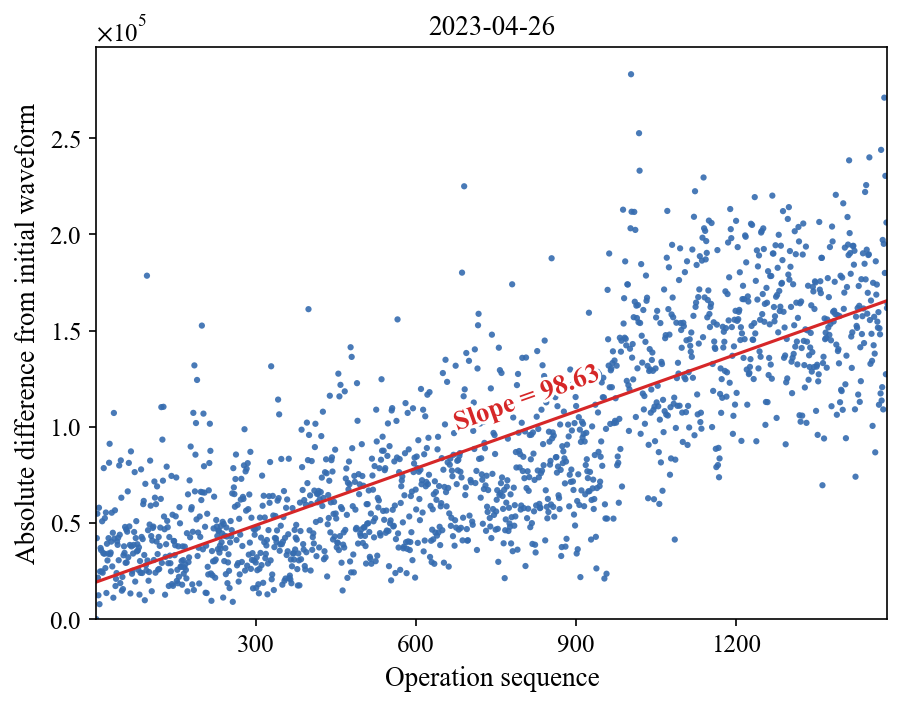

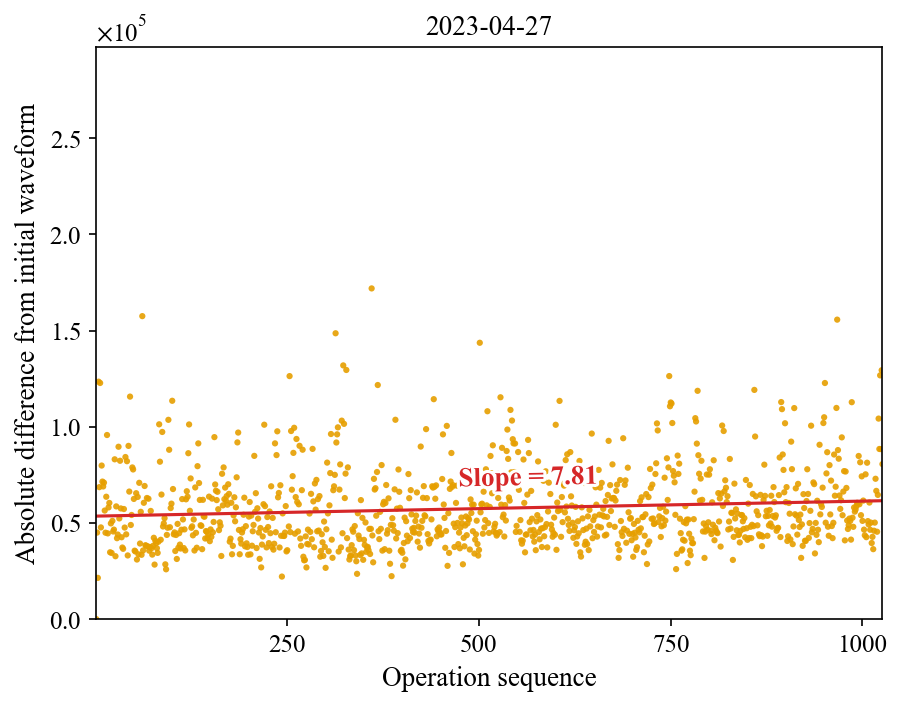

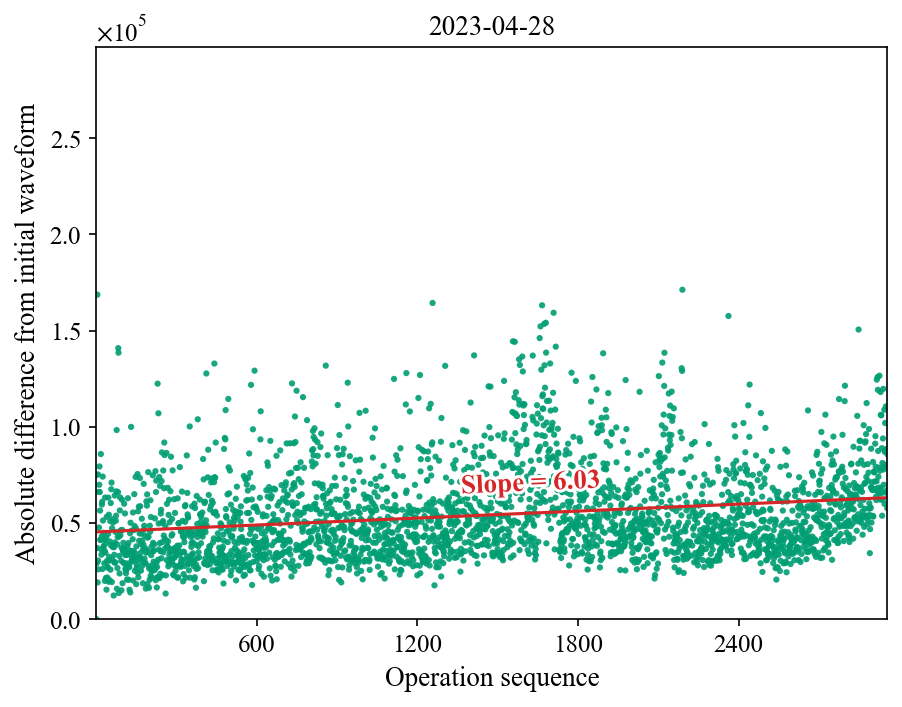

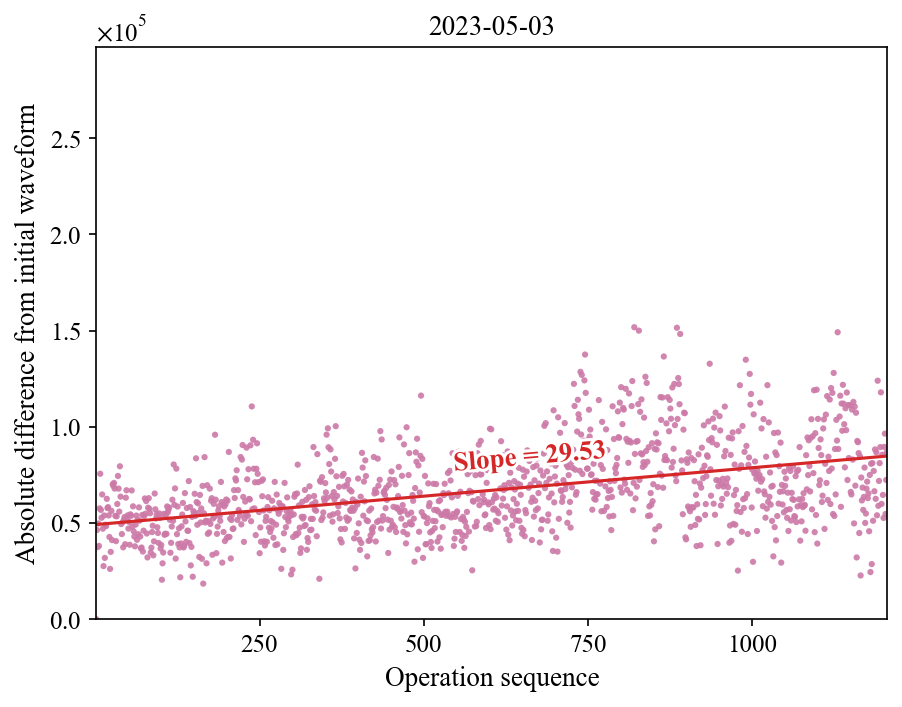

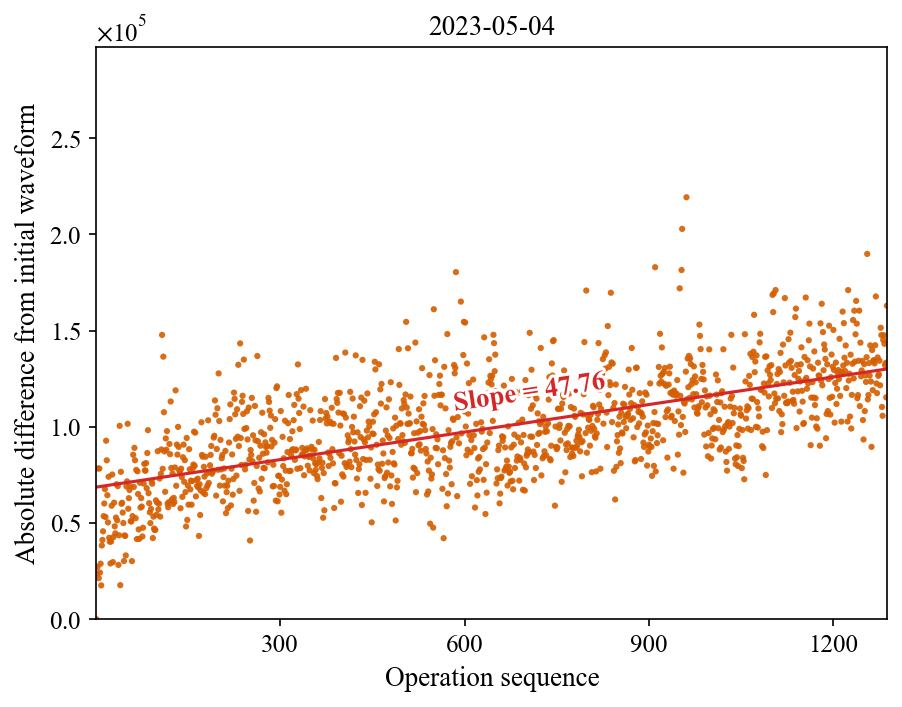

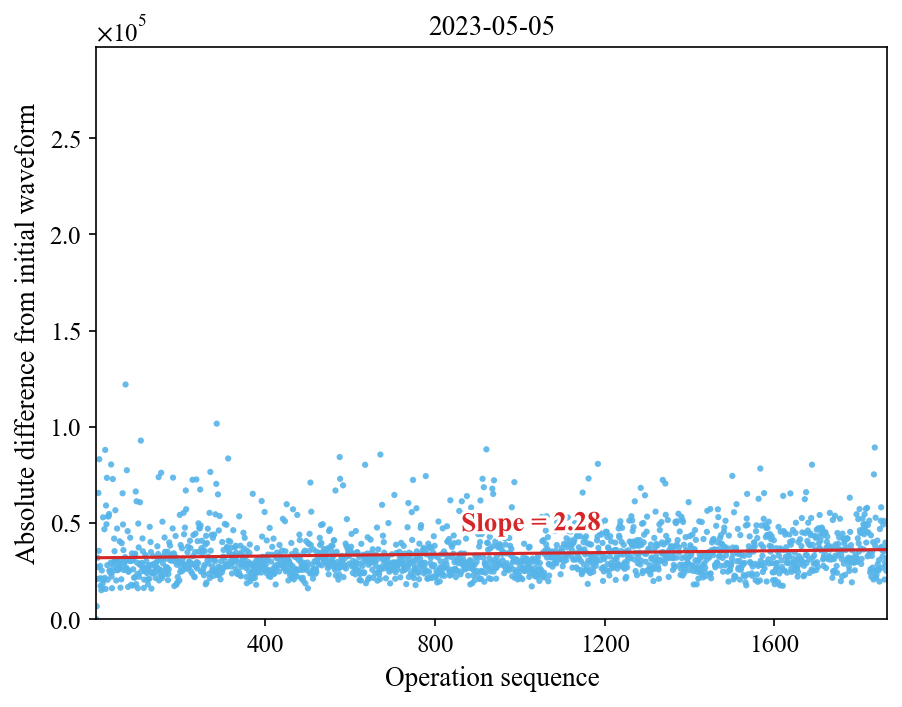

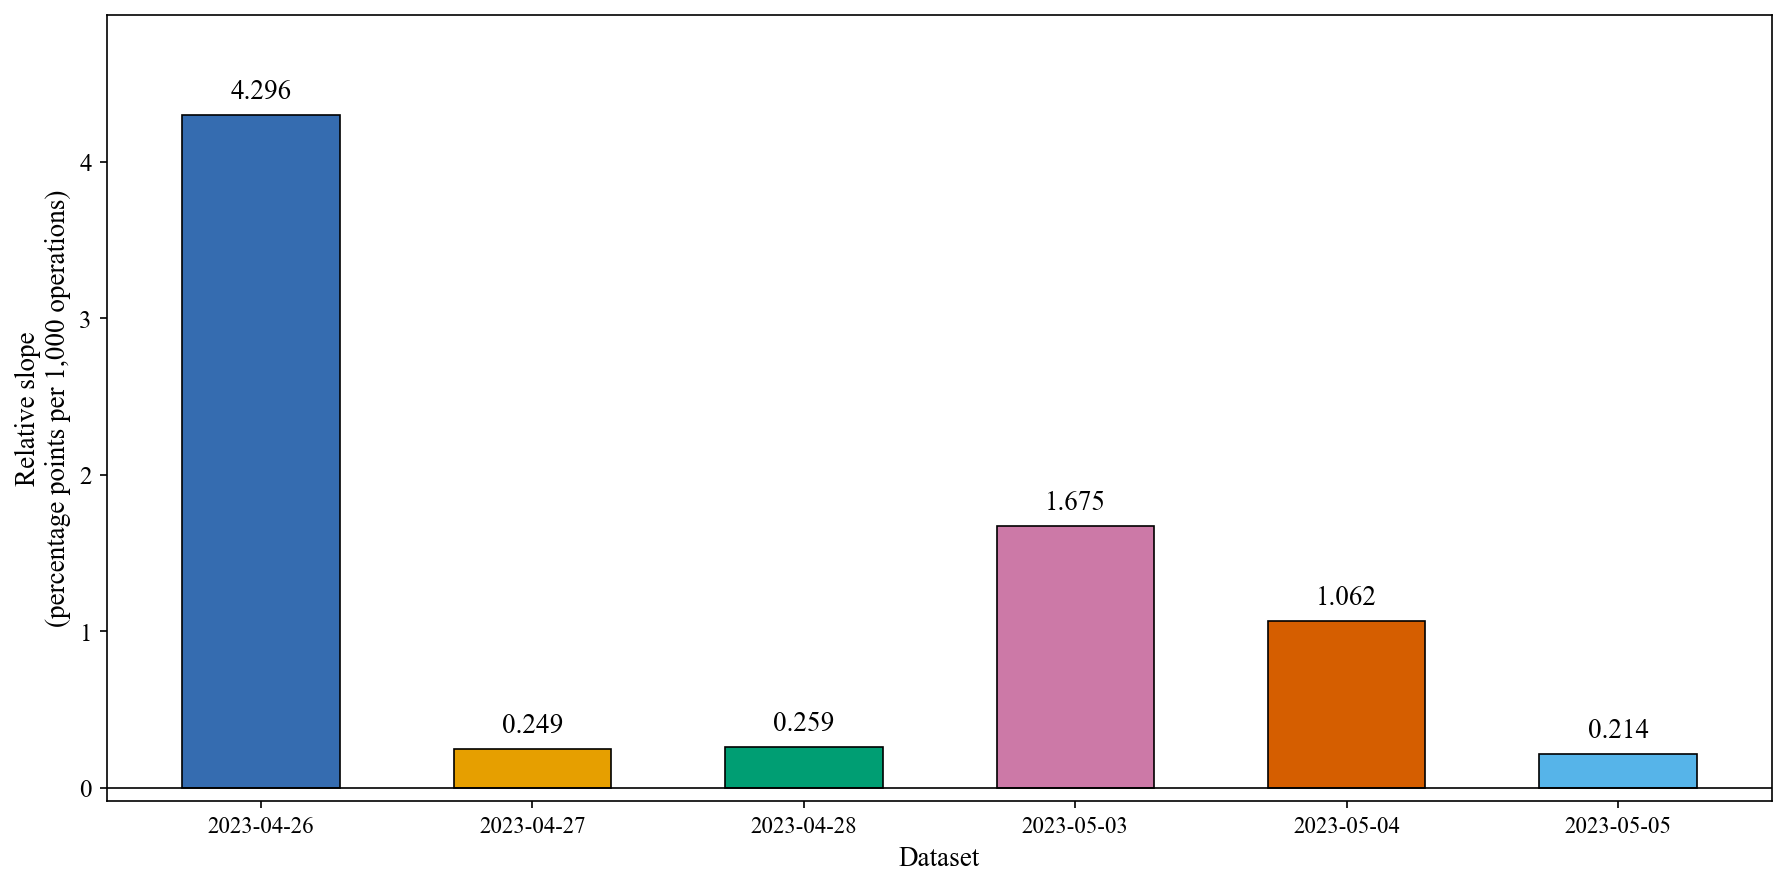

In [12]:
plot_drift(drift_results)
plot_relative_slopes(drift_results)

## 4. Autoencoder monitoring

The first five known-normal waveforms initialize the AE, scaler, and reference.
The threshold is three times the mean of five held-out errors, calibrated without the minimum
scaling divisor. Final training uses the minimum divisor defined by the 10th percentile of
positive initial standard deviations. The AE and scaler remain fixed during monitoring.

In [13]:
def fit_model(initial, stabilize=True):
    scaler = StandardScaler().fit(initial)
    minimum_scale = 0.0
    if stabilize:
        positive_std = np.sqrt(scaler.var_[scaler.var_ > 0])
        if not len(positive_std):
            raise ValueError("Positive initial variance is required for standardization.")
        minimum_scale = float(np.quantile(positive_std, MIN_STD_QUANTILE))
        scaler.scale_ = np.maximum(scaler.scale_, minimum_scale)
    z = scaler.transform(initial)
    model = MLPRegressor(
        hidden_layer_sizes=HIDDEN_LAYERS, activation="relu", solver="adam",
        learning_rate_init=LEARNING_RATE, max_iter=MAX_EPOCHS,
        random_state=SEED, early_stopping=False,
    )
    model.fit(z, z)
    return scaler, model, minimum_scale


def initial_error_mean(data):
    rows = []
    for held in range(TRAIN_COUNT):
        keep = np.arange(TRAIN_COUNT) != held
        scaler, model, _ = fit_model(data["initial"][keep], stabilize=False)
        z = scaler.transform(data["initial"][held:held + 1])
        error = float(np.mean((z - model.predict(z)) ** 2))
        rows.append({"Dataset": data["date"],
                     "Held-out operation": int(data["initial_operations"][held]),
                     "Reconstruction error": error, "Epochs": model.n_iter_})
    return np.mean([row["Reconstruction error"] for row in rows]), rows


def monitor(measured, reference, scaler, model, alphas, thresholds):
    weights = np.asarray(alphas, dtype=np.float32)[:, None]
    thresholds = np.asarray(thresholds, dtype=float)
    drift = np.zeros((len(weights), measured.shape[1]), dtype=np.float32)
    errors = np.empty((len(measured), len(weights)))
    for i, waveform in enumerate(measured):
        z = scaler.transform(waveform[None, :] - drift)
        errors[i] = np.mean((z - model.predict(z)) ** 2, axis=1)
        accepted = errors[i] <= thresholds
        drift[accepted] = (weights[accepted] * drift[accepted]
                           + (1 - weights[accepted]) * (waveform - reference))
    return errors


def summarize(data, errors, threshold):
    normal = data["labels"] == 0
    rejected = errors > threshold
    defects = int((~normal).sum())
    detected = int(rejected[~normal].sum())
    return {
        "Normal samples": int(normal.sum()), "Mean error (normal samples)": errors[normal].mean(),
        "False alarms": int(rejected[normal].sum()),
        "False alarm rate (%)": 100 * rejected[normal].mean(),
        "Detected defects": detected, "Defects": defects,
        "Missed defects": defects - detected,
        "Detection rate (%)": 100 * detected / defects if defects else np.nan,
    }

Each waveform is scored using the preceding drift estimate. The estimate is updated only
after the compensated score satisfies the threshold; subsequent labels are used for evaluation.

In [14]:
results, metric_rows, initialization_rows, fold_rows, defect_rows = {}, [], [], [], []
for date, data in datasets.items():
    mean_error, rows = initial_error_mean(data)
    fold_rows.extend(rows)
    threshold = THRESHOLD_MULTIPLIER * mean_error
    scaler, model, minimum_divisor = fit_model(data["initial"])
    standardized = scaler.transform(data["measured"])
    conditions = {
        "Without EMA": np.mean((standardized - model.predict(standardized)) ** 2, axis=1),
        "With EMA": monitor(data["measured"], data["reference"], scaler, model,
                            [ALPHA], [threshold])[:, 0],
    }
    initialization_rows.append({
        "Dataset": date, "Held-out mean": mean_error, "Threshold": threshold,
        "Minimum scaling divisor": minimum_divisor, "Epochs": model.n_iter_,
        "SHA256": data["sha256"],
    })
    for condition, errors in conditions.items():
        metric_rows.append({"Dataset": date, "Condition": condition,
                            "Threshold": threshold, **summarize(data, errors, threshold)})
    for i in np.flatnonzero(data["labels"] == 1):
        defect_rows.append({
            "Dataset": date, "Operation": int(data["operation"][i]), "Threshold": threshold,
            **{condition: errors[i] for condition, errors in conditions.items()},
        })
    results[date] = {"data": data, "scaler": scaler, "model": model,
                     "threshold": threshold, "conditions": conditions}

metrics = pd.DataFrame(metric_rows)
initialization = pd.DataFrame(initialization_rows)
folds = pd.DataFrame(fold_rows)
defect_errors = pd.DataFrame(defect_rows)
totals = metrics.groupby("Condition", sort=False)[
    ["Normal samples", "False alarms", "Defects", "Detected defects", "Missed defects"]
].sum().reset_index()
totals["False alarm rate (%)"] = 100 * totals["False alarms"] / totals["Normal samples"]
totals["Detection rate (%)"] = 100 * totals["Detected defects"] / totals["Defects"].replace(0, np.nan)
table(metrics)
table(totals)

C:\Users\E150_Jinwoo\tf_gpu_env310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Dataset,Condition,Threshold,Normal samples,Mean error (normal samples),False alarms,False alarm rate (%),Detected defects,Defects,Missed defects,Detection rate (%)
2023-04-26,Without EMA,12.8560,1479,17.8676,636,43.0020,1,1,0,100.0000
2023-04-26,With EMA,12.8560,1479,2.0803,18,1.2170,1,1,0,100.0000
2023-04-27,Without EMA,18.3111,1019,1.6391,0,0.0000,2,2,0,100.0000
2023-04-27,With EMA,18.3111,1019,0.7798,0,0.0000,2,2,0,100.0000
2023-04-28,Without EMA,13.3030,2941,1.4271,2,0.0680,10,10,0,100.0000
2023-04-28,With EMA,13.3030,2941,0.3345,1,0.0340,10,10,0,100.0000
2023-05-03,Without EMA,14.7796,1194,9.4580,227,19.0117,8,8,0,100.0000
2023-05-03,With EMA,14.7796,1194,3.0200,3,0.2513,8,8,0,100.0000
2023-05-04,Without EMA,10.1165,1283,11.2652,627,48.8698,0,0,0,—
2023-05-04,With EMA,10.1165,1283,1.5258,5,0.3897,0,0,0,—


Condition,Normal samples,False alarms,Defects,Detected defects,Missed defects,False alarm rate (%),Detection rate (%)
Without EMA,9773,1503,26,26,0,15.3791,100.0000
With EMA,9773,32,26,26,0,0.3274,100.0000


### Reconstruction errors of normal samples

In [15]:
def _draw_normal_errors(ax, data, errors, threshold, title, ymax, color):
    normal = data["labels"] == 0
    ax.scatter(data["operation"][normal], errors[normal], s=9, marker="o",
               color=color, alpha=0.9, edgecolors="none", rasterized=True)
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1,
               label=f"Threshold = {threshold:.2f}")
    span = data["operation"][-1] - data["operation"][0]
    ax.set_xlim(data["operation"][0] - 0.02 * span,
                data["operation"][-1] + 0.02 * span)
    ax.set_ylim(0, ymax)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.tick_params(axis="y", labelleft=True)
    ax.set_xlabel("Operation sequence")
    ax.set_ylabel("Reconstruction error")
    ax.set_title(f"{data['date']} — {title}", fontsize=13)
    ax.legend(loc="upper left", fontsize=10, frameon=True)
    count = int(np.sum(errors[normal] > threshold))
    ax.text(0.5, 0.5, f"False alarms: {count}", transform=ax.transAxes,
            ha="center", va="center", color="#D62728", fontsize=18,
            fontweight="bold", bbox={"facecolor": "white", "edgecolor": "none",
                                     "alpha": 0.85, "pad": 3})


def plot_normal_errors(results):
    with plt.rc_context(_PLOT_STYLE):
        for (date, result), color in zip(results.items(), COLORS):
            data = result["data"]
            normal = data["labels"] == 0
            ymax = 1.1 * max(
                result["threshold"],
                max(errors[normal].max() for errors in result["conditions"].values()),
            )
            fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.6), layout="constrained",
                                     sharex=True, sharey=True)
            for ax, (condition, errors) in zip(axes, result["conditions"].items()):
                _draw_normal_errors(ax, data, errors, result["threshold"],
                                    condition, ymax, color)
            show_figure(fig)

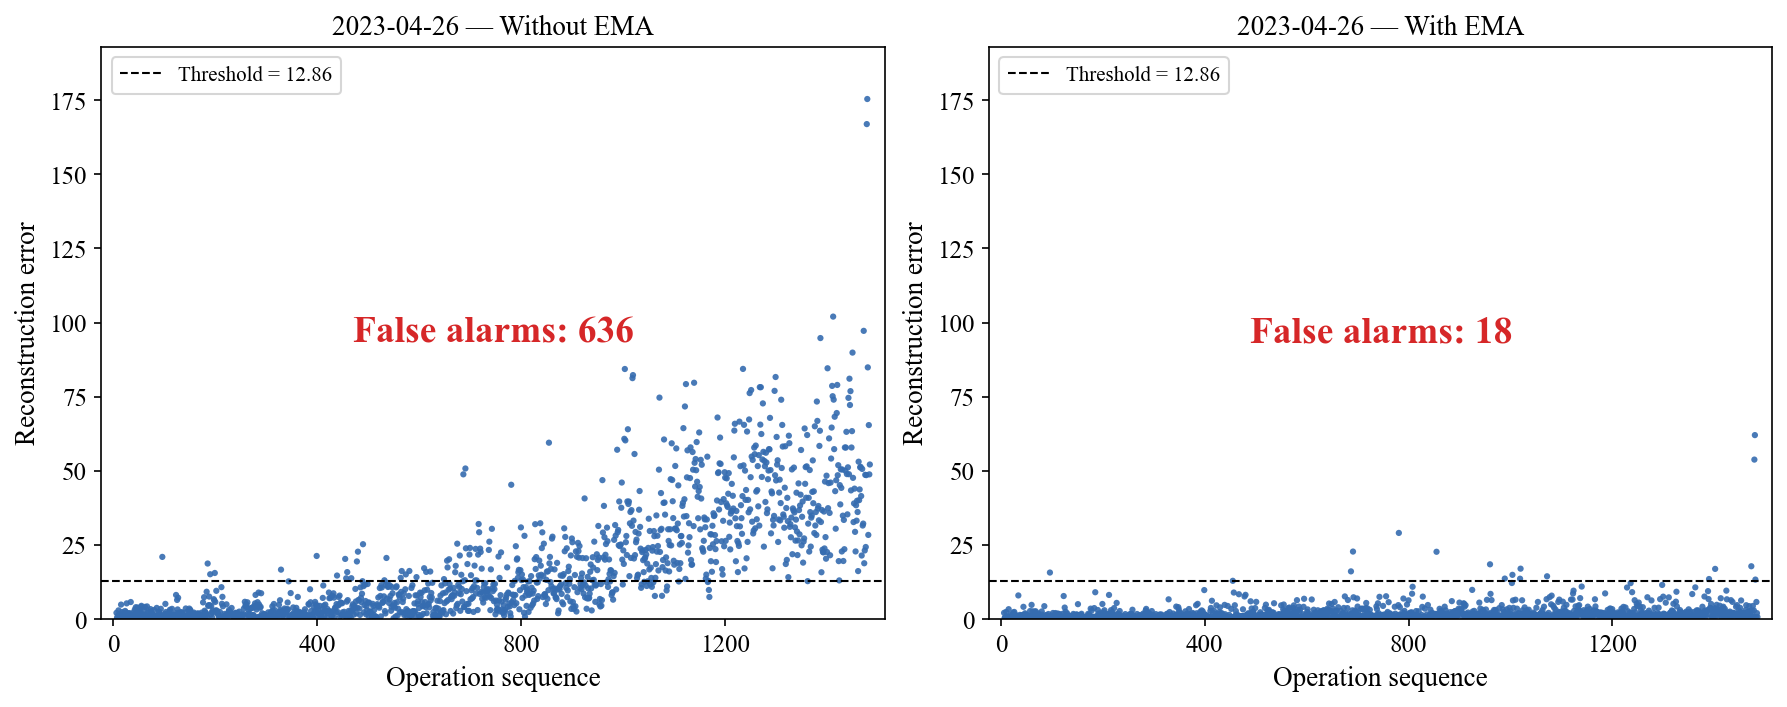

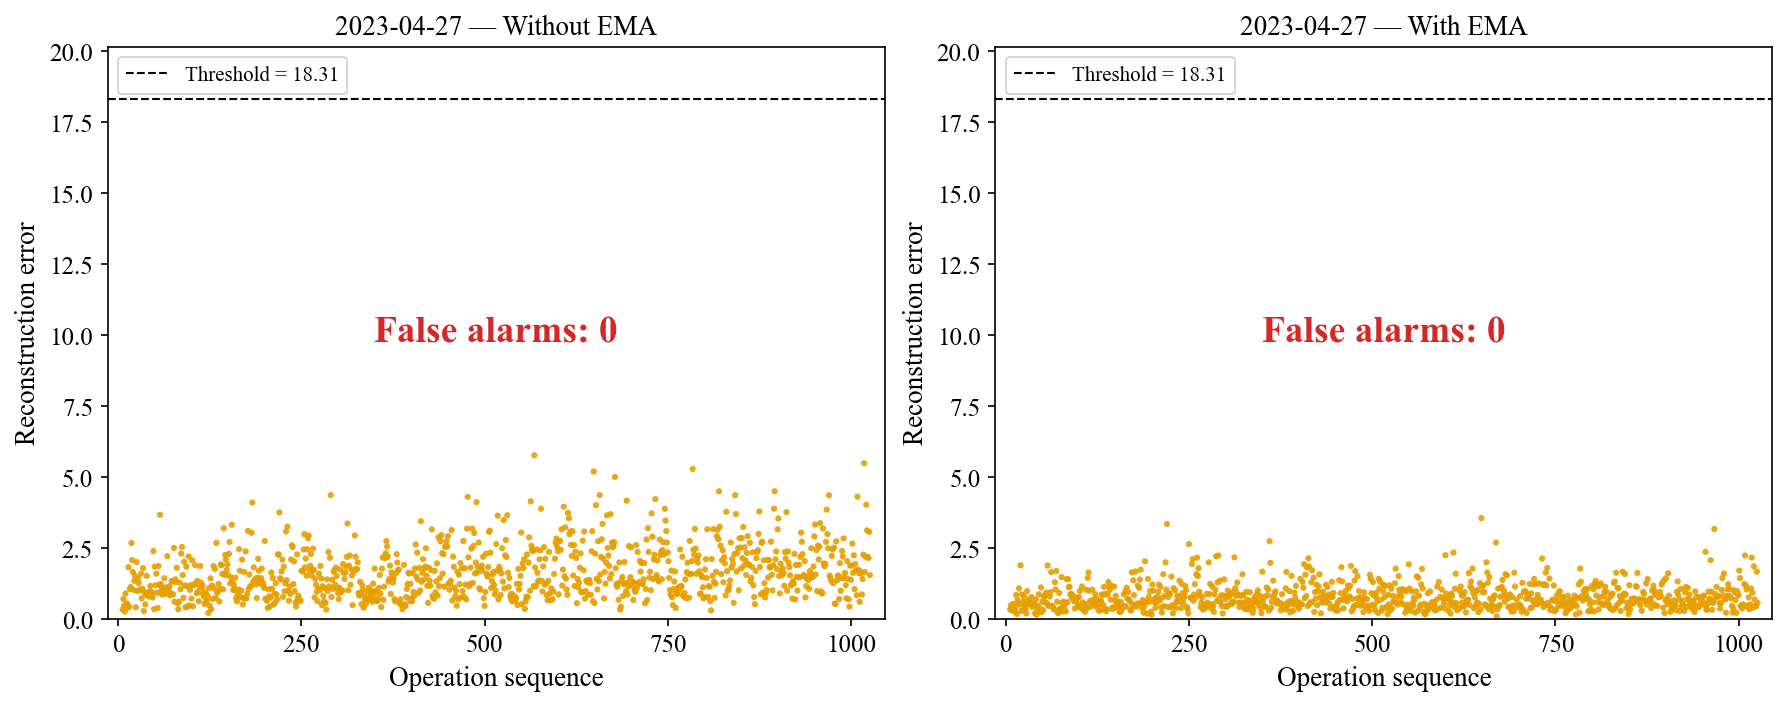

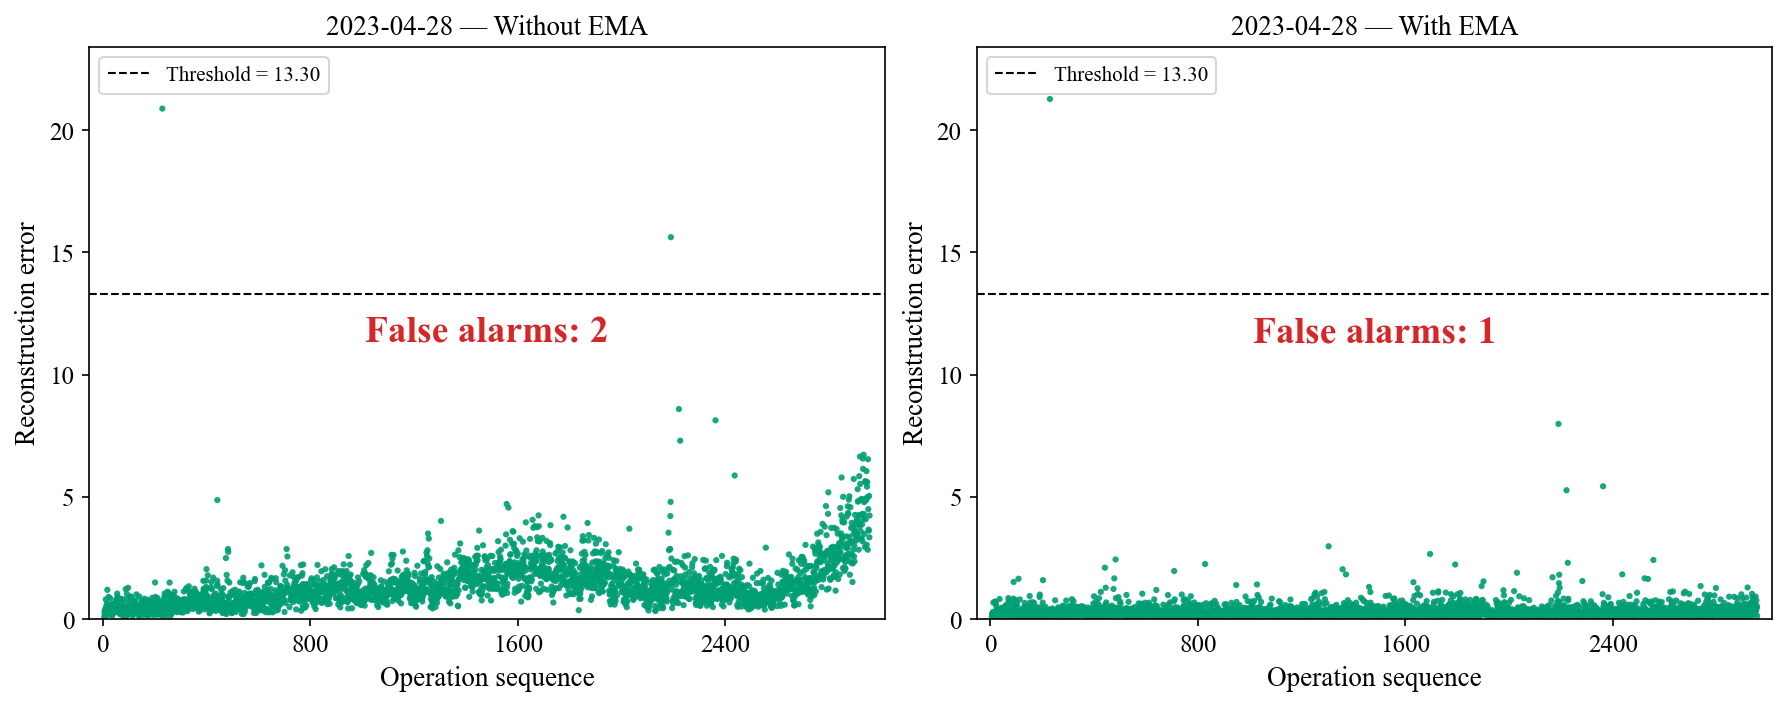

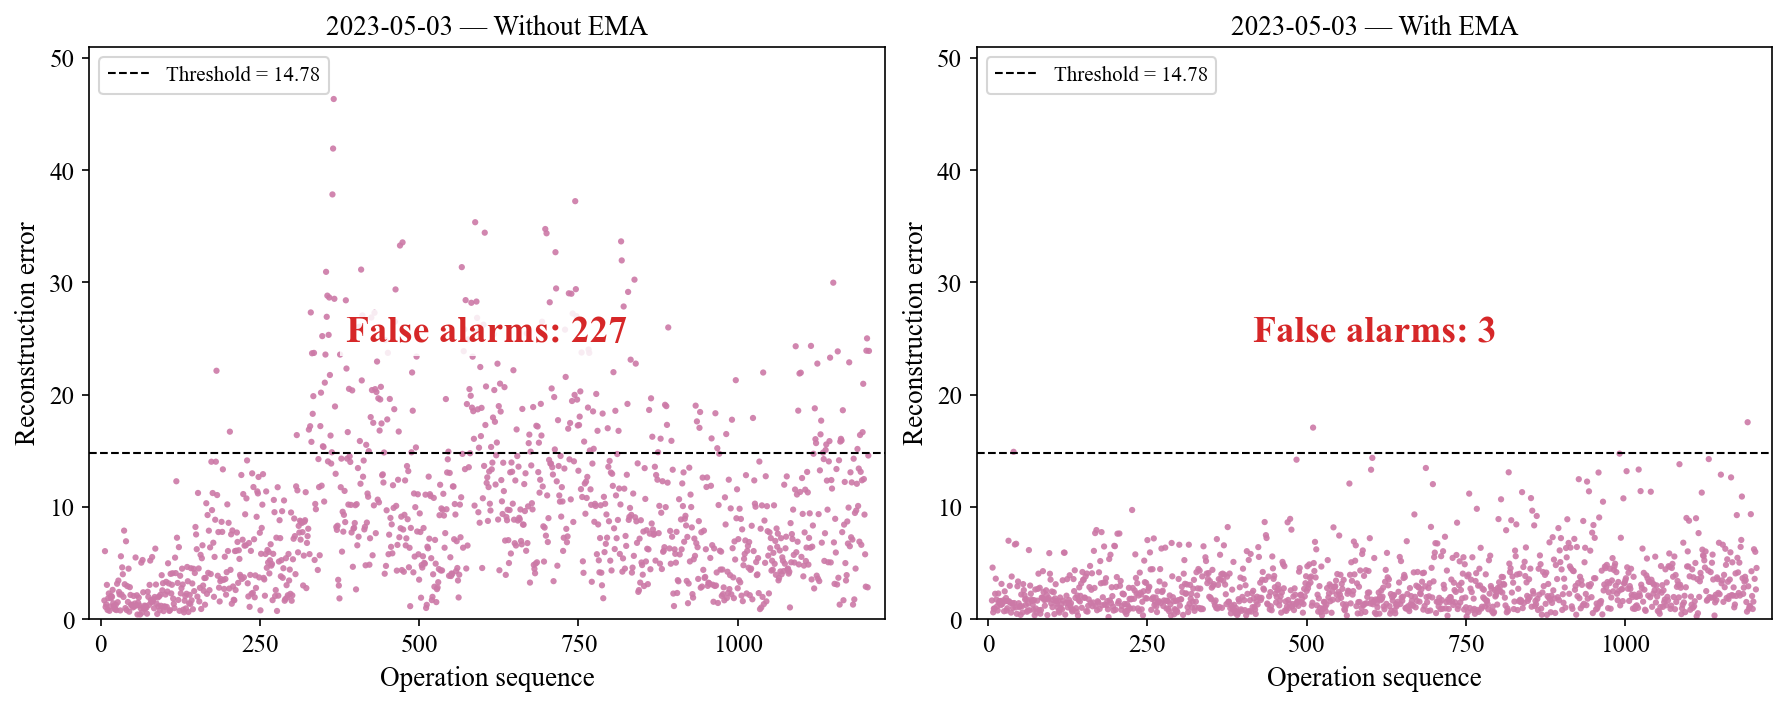

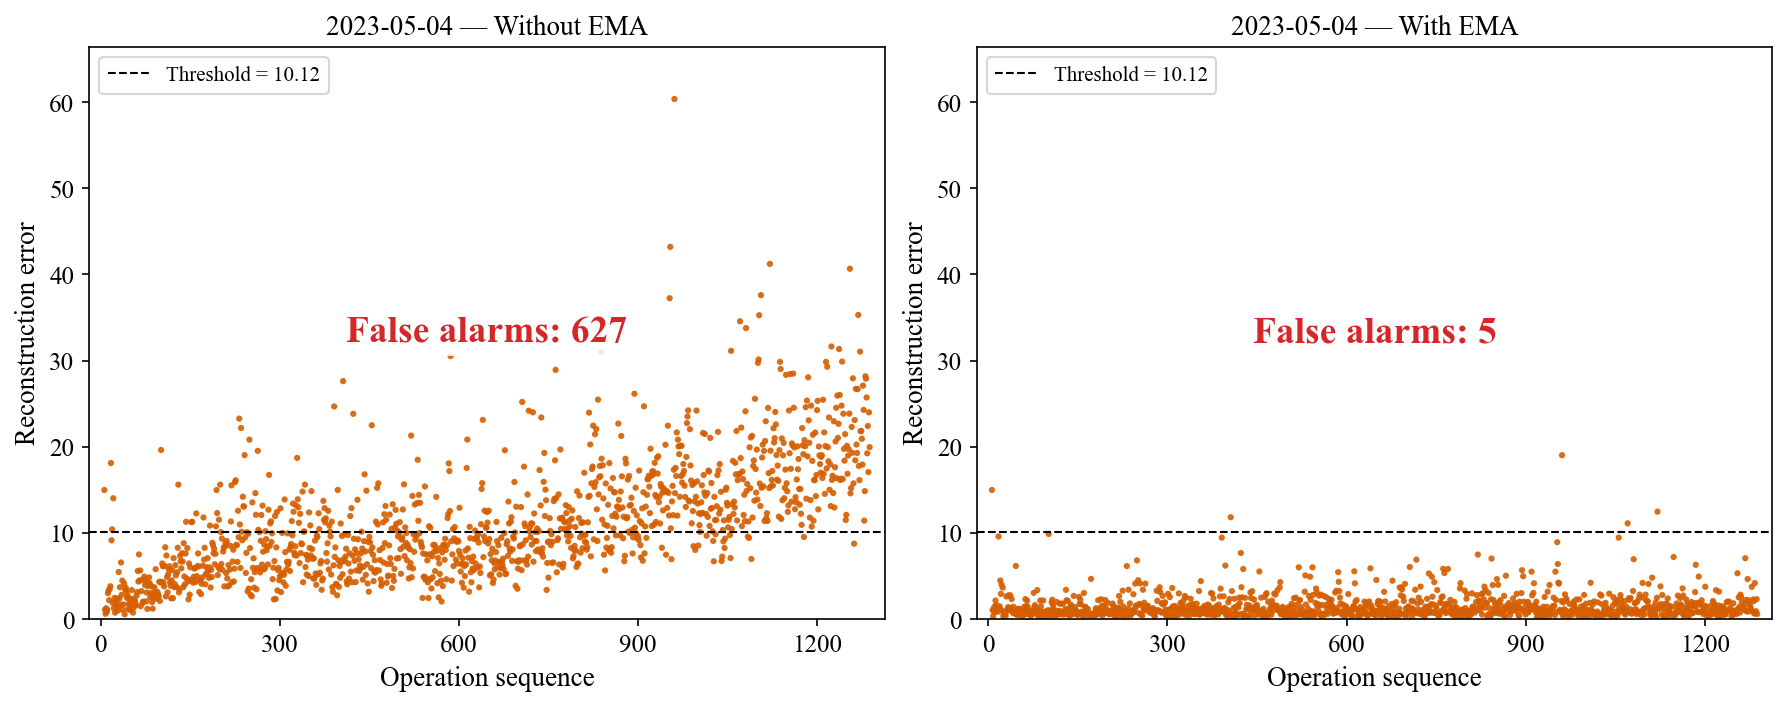

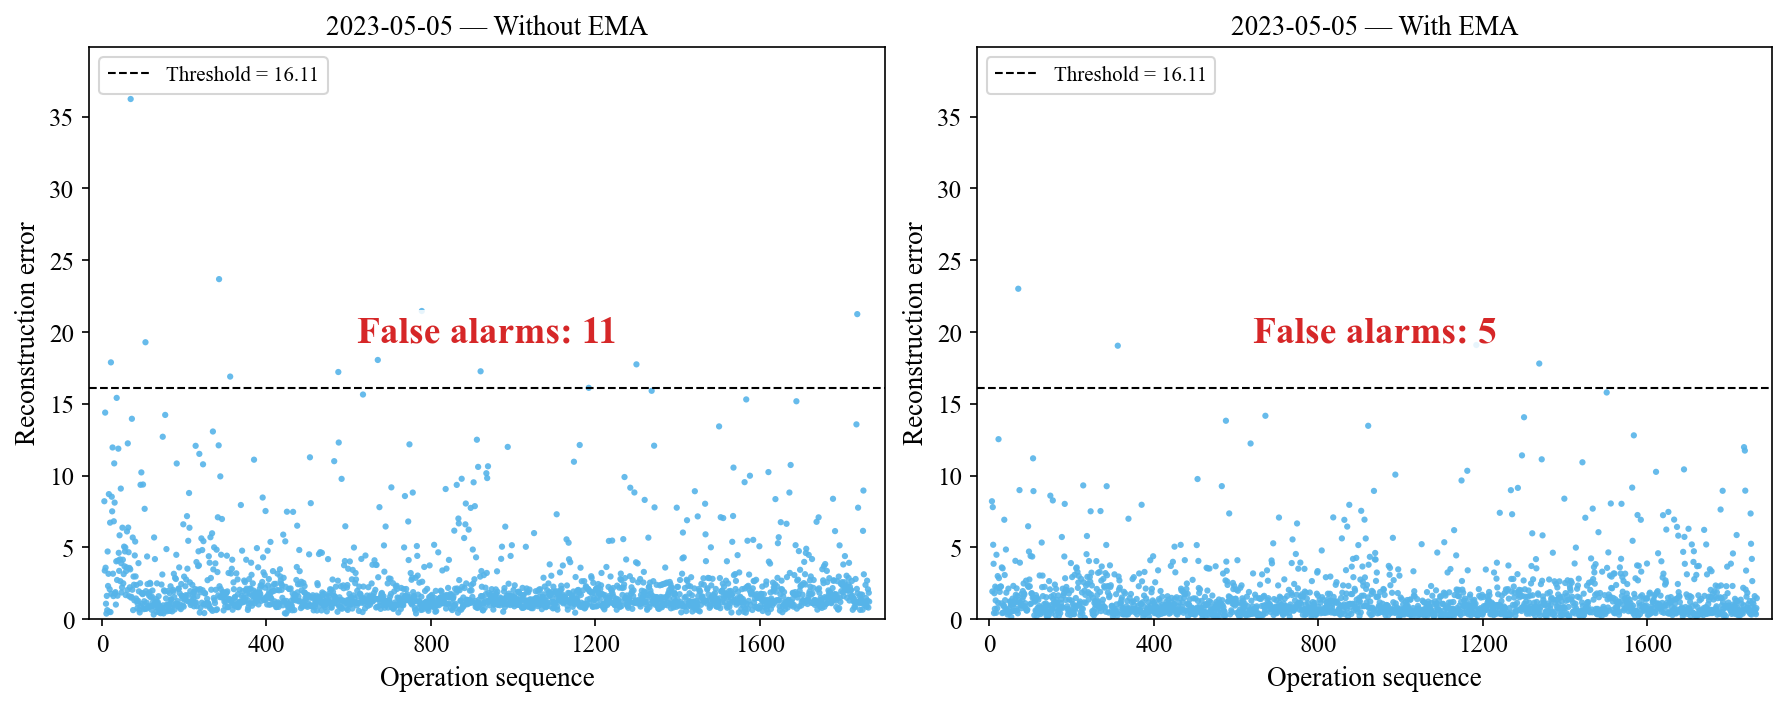

In [16]:
plot_normal_errors(results)

## 5. Sensitivity to the EMA smoothing factor

Each alpha is evaluated with an independently reset drift estimate, using the same fixed AE,
scaler, reference, and threshold. False-alarm rates exclude the initialization samples.

In [17]:
sensitivity_rows = []
for date, result in results.items():
    data, threshold = result["data"], result["threshold"]
    errors = monitor(data["measured"], data["reference"], result["scaler"], result["model"],
                     ALPHAS, np.full(len(ALPHAS), threshold))
    normal = data["labels"] == 0
    for k, alpha in enumerate(ALPHAS):
        rejected = errors[:, k] > threshold
        sensitivity_rows.append({
            "Dataset": date, "Alpha": alpha, "Threshold": threshold,
            "False alarms": int(rejected[normal].sum()),
            "False alarm rate (%)": 100 * rejected[normal].mean(),
            "Detected defects": int(rejected[~normal].sum()),
            "Defects": int((~normal).sum()),
        })
sensitivity_metrics = pd.DataFrame(sensitivity_rows)

In [18]:
def plot_sensitivity(sensitivity_metrics, drift_summary):
    with plt.rc_context(_PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(11.8, 5.8))
        fig.subplots_adjust(left=0.09, right=0.66, bottom=0.14, top=0.90)
        slopes = drift_summary.set_index("Dataset")[
            "Relative slope (pp per 1,000 operations)"
        ]
        endpoints = []
        dates = sensitivity_metrics["Dataset"].drop_duplicates()
        for date, color, marker in zip(dates, COLORS, MARKERS):
            subset = sensitivity_metrics.loc[
                sensitivity_metrics["Dataset"].eq(date)
            ].sort_values("Alpha")
            ax.plot(subset["Alpha"], subset["False alarm rate (%)"], color=color,
                    marker=marker, markersize=6, linewidth=1.6)
            timestamp = pd.Timestamp(date)
            label = (f"{timestamp.month_name()} {timestamp.day} "
                     f"(Relative Slope: {slopes.loc[date]:.3f})")
            endpoints.append((subset["Alpha"].iloc[-1],
                              subset["False alarm rate (%)"].iloc[-1], color, label))
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel("False alarm rate (%)")
        ax.set_xticks(ALPHAS, labels=[f"{alpha:.2f}" for alpha in ALPHAS])
        ax.tick_params(axis="x", labelsize=11)
        ax.set_xlim(ALPHAS[0] - 0.015, ALPHAS[-1] + 0.012)
        ax.set_ylim(0, max(0.2, sensitivity_metrics["False alarm rate (%)"].max() * 1.15))
        ax.set_title(f"Threshold multiplier = {THRESHOLD_MULTIPLIER:g}")
        fig.canvas.draw()
        font_size = 13
        gap = (font_size * 1.5 / 72 * fig.dpi) / ax.bbox.height
        label_positions = []
        for x, y, color, label in sorted(endpoints, key=lambda item: item[1]):
            position = ax.transAxes.inverted().transform(ax.transData.transform((x, y)))[1]
            position = max(position, gap / 2)
            if label_positions:
                position = max(position, label_positions[-1][0] + gap)
            label_positions.append((position, x, y, color, label))
        for position, x, y, color, label in label_positions:
            ax.annotate(
                label, xy=(x, y), xycoords="data", xytext=(1.045, position),
                textcoords="axes fraction", ha="left", va="center", fontsize=font_size,
                color=color, annotation_clip=False,
                arrowprops={"arrowstyle": "-", "color": color, "linewidth": 0.9,
                            "shrinkA": 4, "shrinkB": 5},
            )
        show_figure(fig)

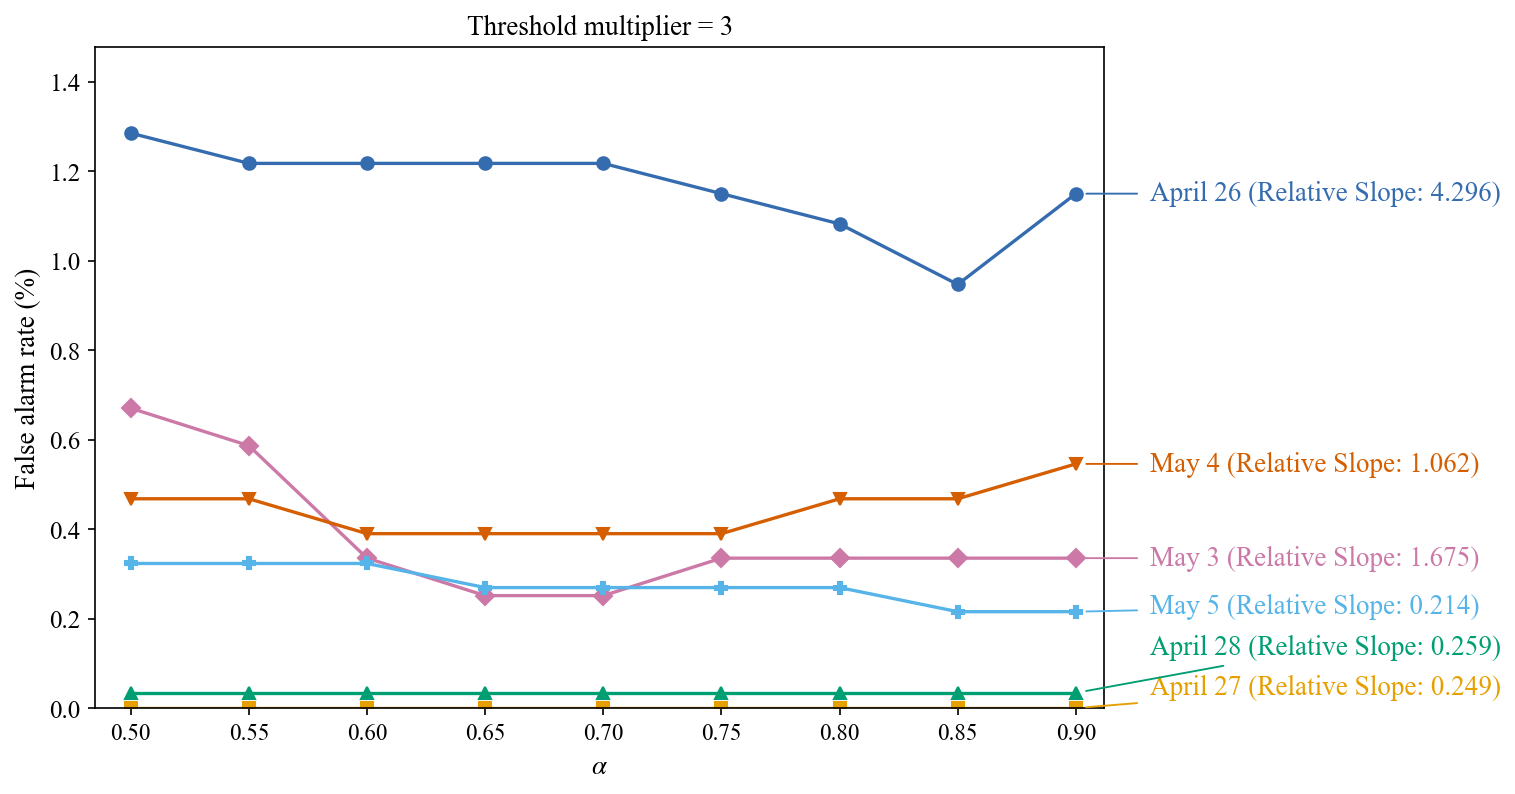

Dataset,Alpha,Threshold,False alarms,False alarm rate (%),Detected defects,Defects
2023-04-26,0.5000,12.8560,19,1.2847,1,1
2023-04-26,0.5500,12.8560,18,1.2170,1,1
2023-04-26,0.6000,12.8560,18,1.2170,1,1
2023-04-26,0.6500,12.8560,18,1.2170,1,1
2023-04-26,0.7000,12.8560,18,1.2170,1,1
2023-04-26,0.7500,12.8560,17,1.1494,1,1
2023-04-26,0.8000,12.8560,16,1.0818,1,1
2023-04-26,0.8500,12.8560,14,0.9466,1,1
2023-04-26,0.9000,12.8560,17,1.1494,1,1
2023-04-27,0.5000,18.3111,0,0.0000,2,2


In [19]:
plot_sensitivity(sensitivity_metrics, drift_summary)
table(sensitivity_metrics)

## 6. Defect detection

Normal and defective samples are compared without EMA and with EMA at alpha 0.7.
The first set of plots focuses on the threshold; values outside the displayed range are plotted
at the boundary. The second set displays the full range. Metrics always use the actual errors.

In [20]:
def plot_defect_errors(results, full_range=False):
    with plt.rc_context(_PLOT_STYLE):
        conditions = ("Without EMA", "With EMA")
        for (date, result), color in zip(results.items(), COLORS):
            data, threshold = result["data"], result["threshold"]
            normal = data["labels"] == 0
            display_limit = 4.0 * threshold
            ymax = (
                1.05 * max(threshold, max(result["conditions"][name].max()
                                         for name in conditions))
                if full_range else display_limit
            )
            fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8))
            fig.subplots_adjust(left=0.07, right=0.99, bottom=0.14, top=0.91, wspace=0.25)
            for ax, condition in zip(axes, conditions):
                errors = result["conditions"][condition]
                above = errors > display_limit
                for mask, marker, sample_color, size, label in [
                    (normal, "o", color, 10, "Normal"),
                    (~normal, "^", "#D62728", 48, "Defective"),
                ]:
                    if full_range:
                        ax.scatter(data["operation"][mask], errors[mask], s=size,
                                   marker=marker, color=sample_color, alpha=0.9,
                                   edgecolors="none", zorder=3 if label == "Normal" else 4,
                                   label=label)
                    else:
                        inside = mask & ~above
                        ax.scatter(data["operation"][inside], errors[inside], s=size,
                                   marker=marker, color=sample_color, alpha=0.9,
                                   edgecolors="none", zorder=3, label=label)
                        outside = mask & above
                        ax.scatter(data["operation"][outside],
                                   np.full(outside.sum(), display_limit), s=size,
                                   marker=marker, color=sample_color, alpha=0.9,
                                   edgecolors="none", zorder=4)
                ax.axhline(threshold, color="black", linestyle="--", linewidth=1.2,
                           label=f"Threshold = {threshold:.2f}")
                span = np.ptp(data["operation"])
                ax.set_xlim(data["operation"][0] - 0.02 * span,
                            data["operation"][-1] + 0.02 * span)
                ax.set_ylim(0, ymax)
                ax.ticklabel_format(axis="y", style="plain", useOffset=False)
                ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
                ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
                ax.set_xlabel("Operation sequence")
                ax.set_ylabel("Reconstruction error")
                ax.set_title(f"{date} — {condition}", fontsize=13)
                ax.legend(loc="upper left", bbox_to_anchor=(0, 0.93), fontsize=10,
                          frameon=True)
            show_figure(fig)

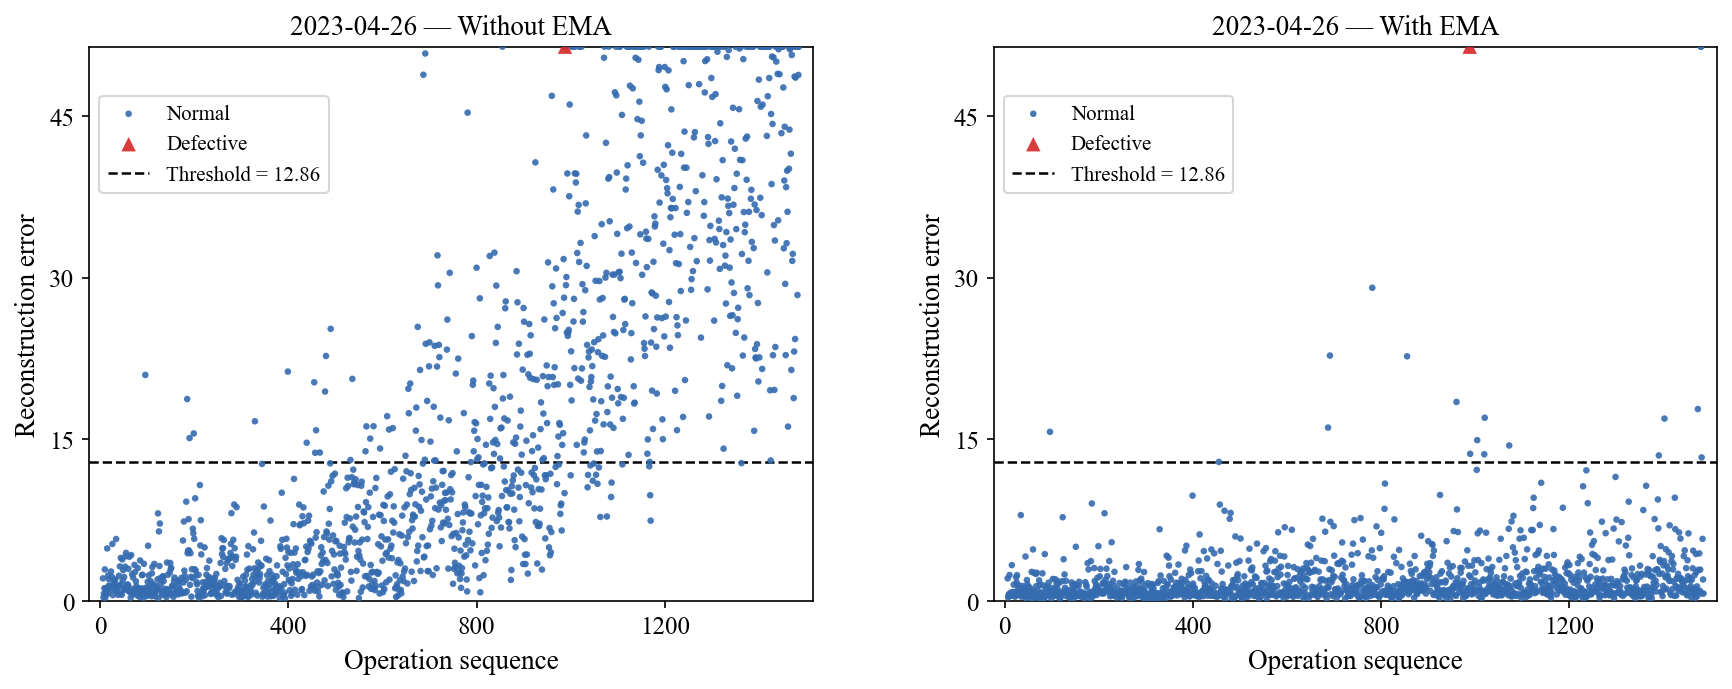

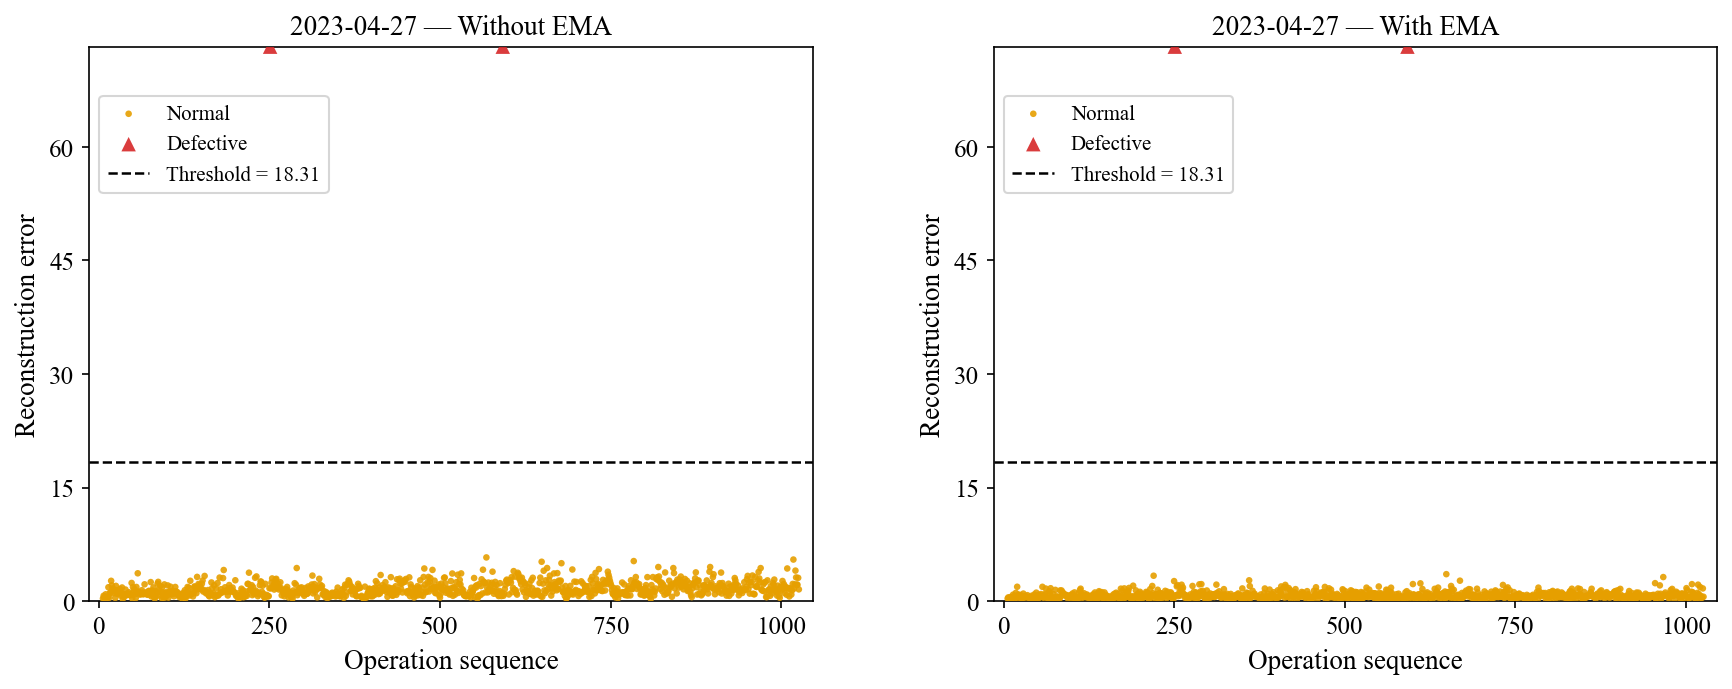

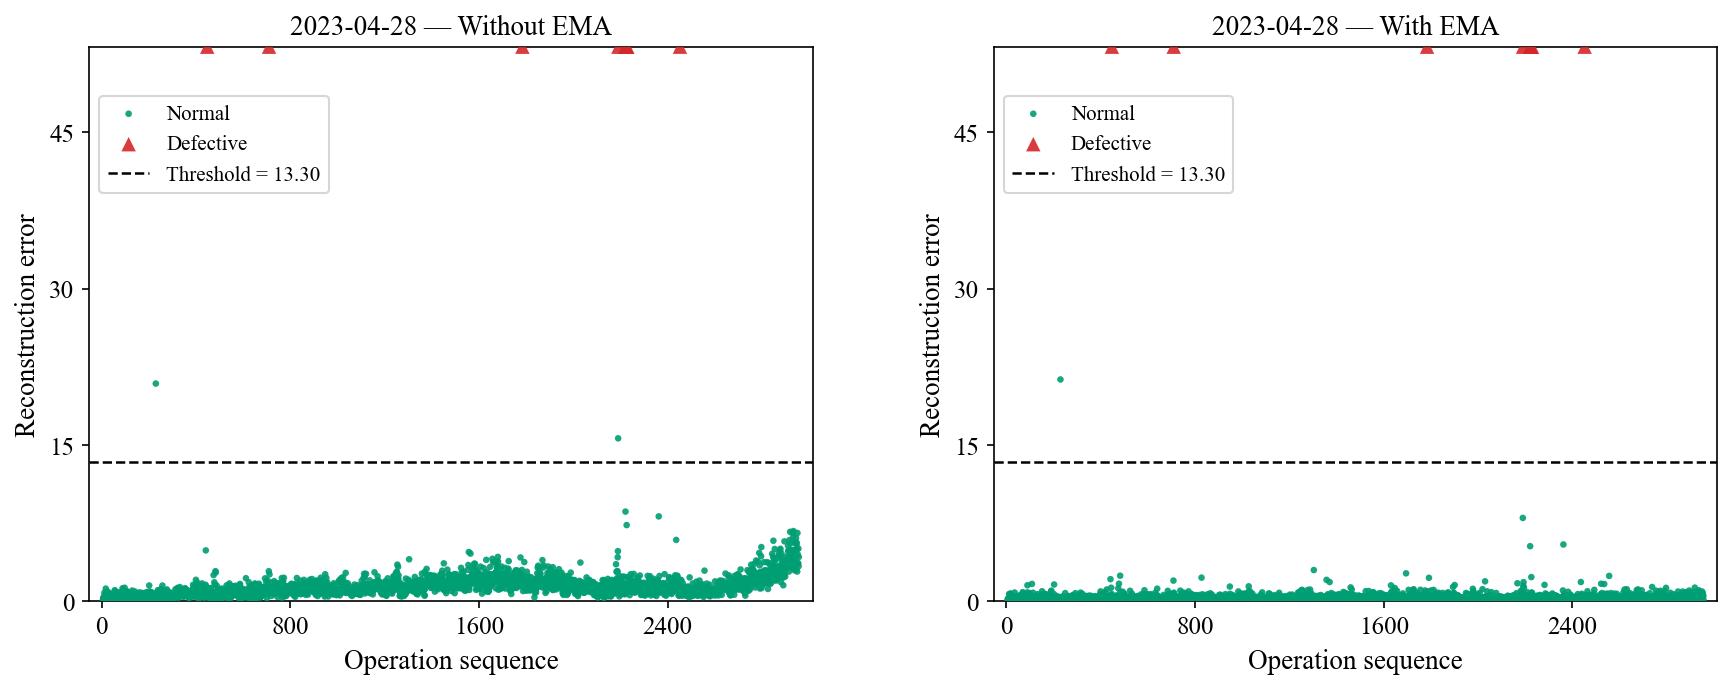

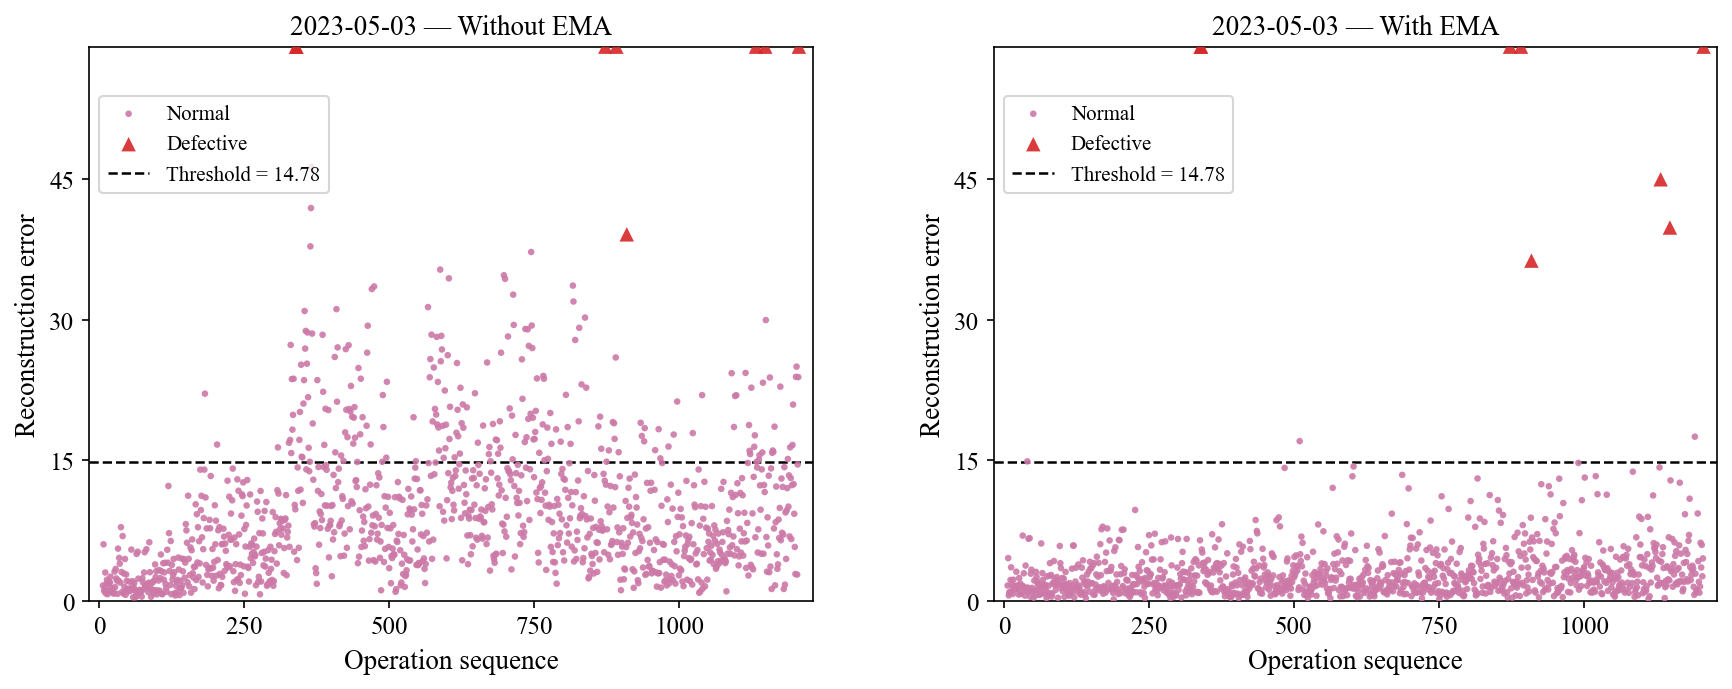

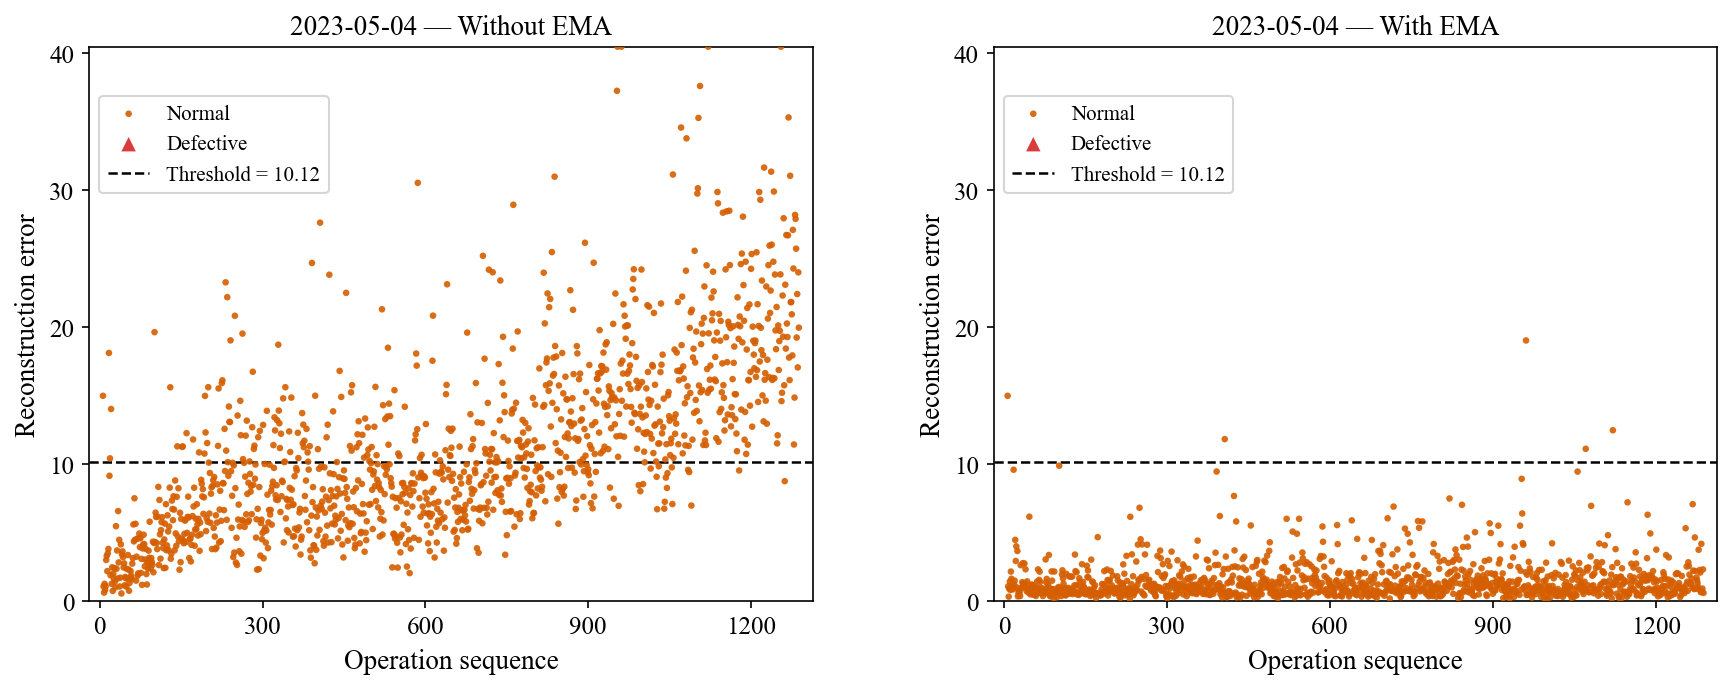

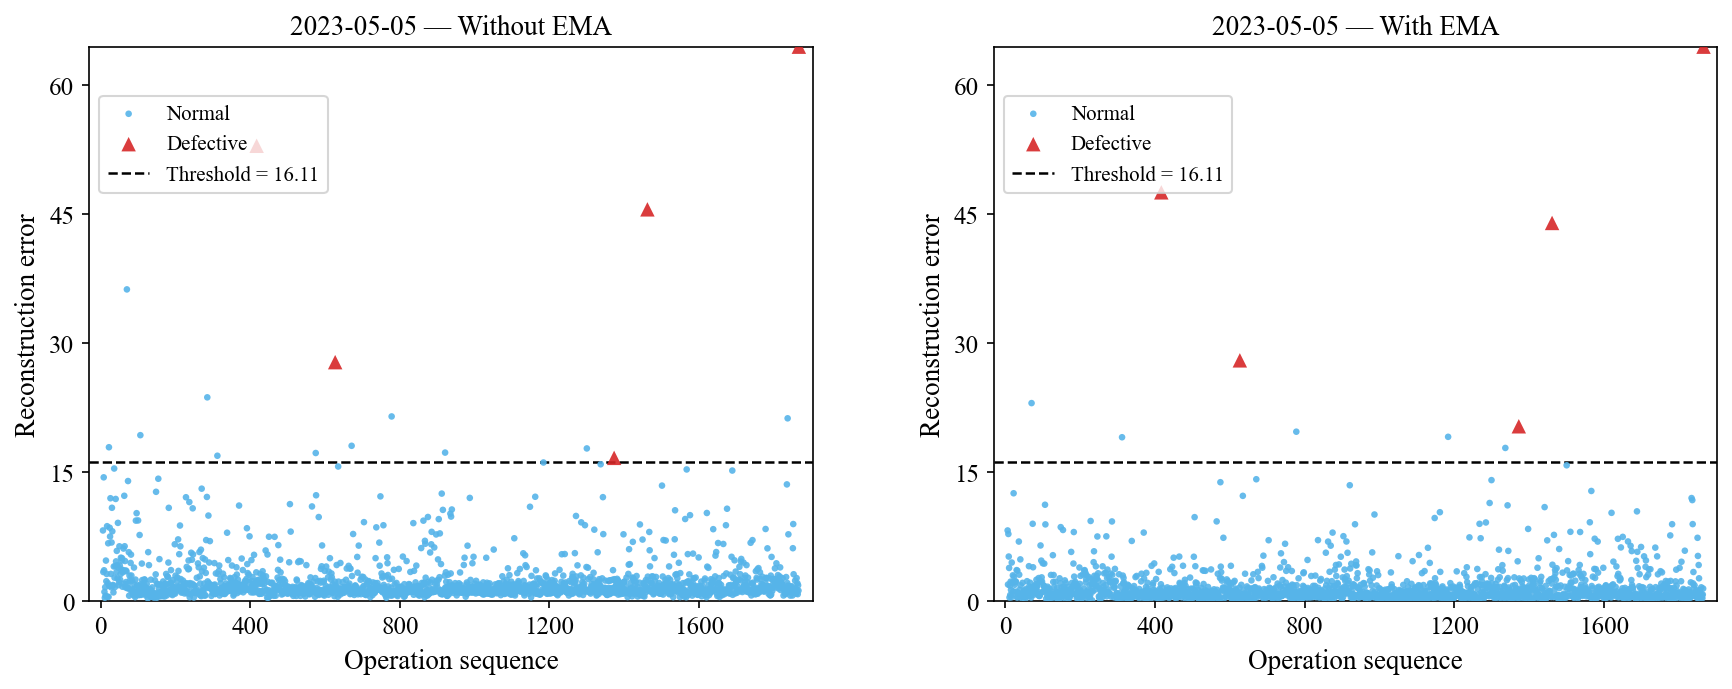

In [21]:
plot_defect_errors(results)

### Full error range

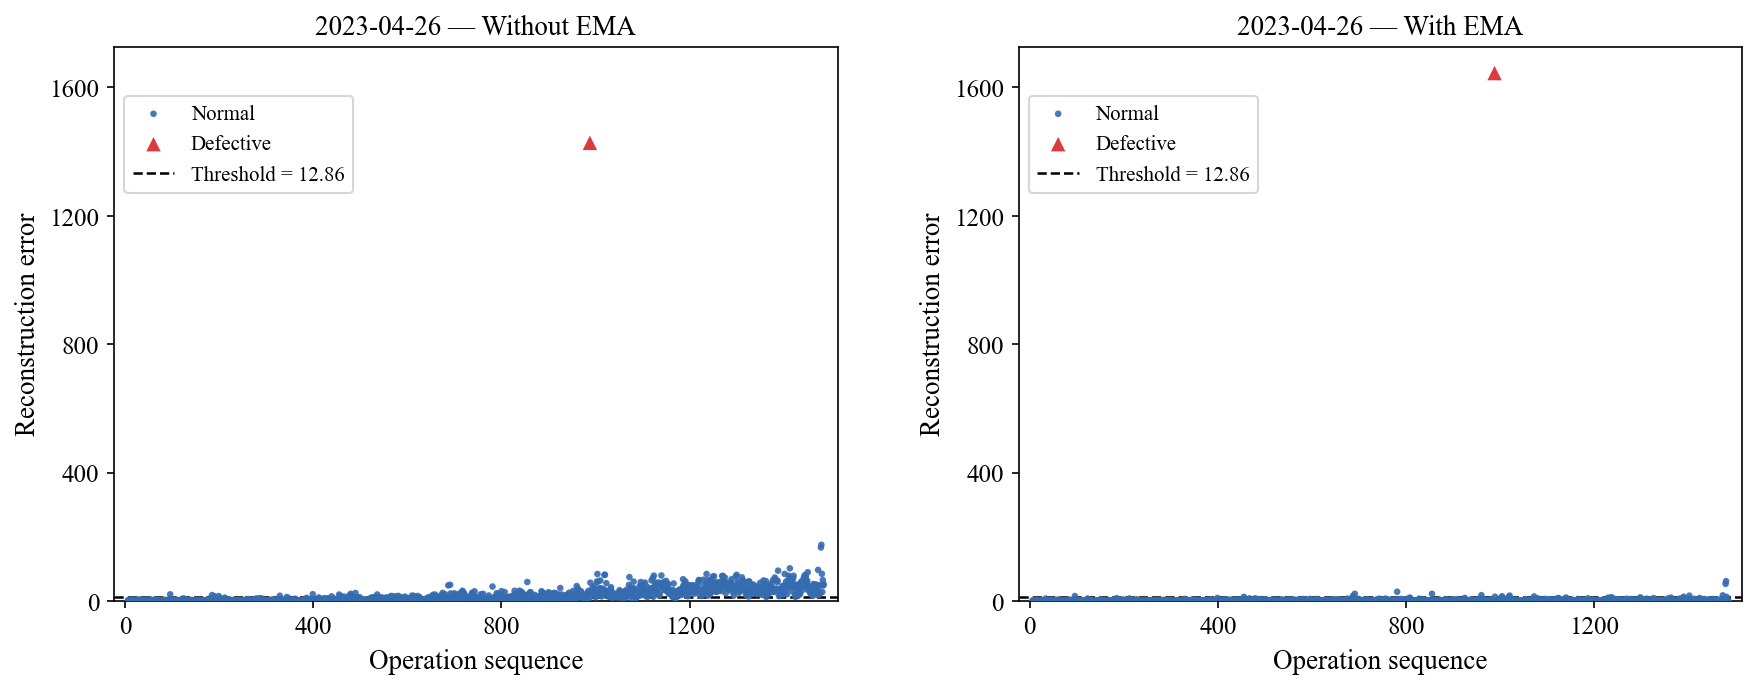

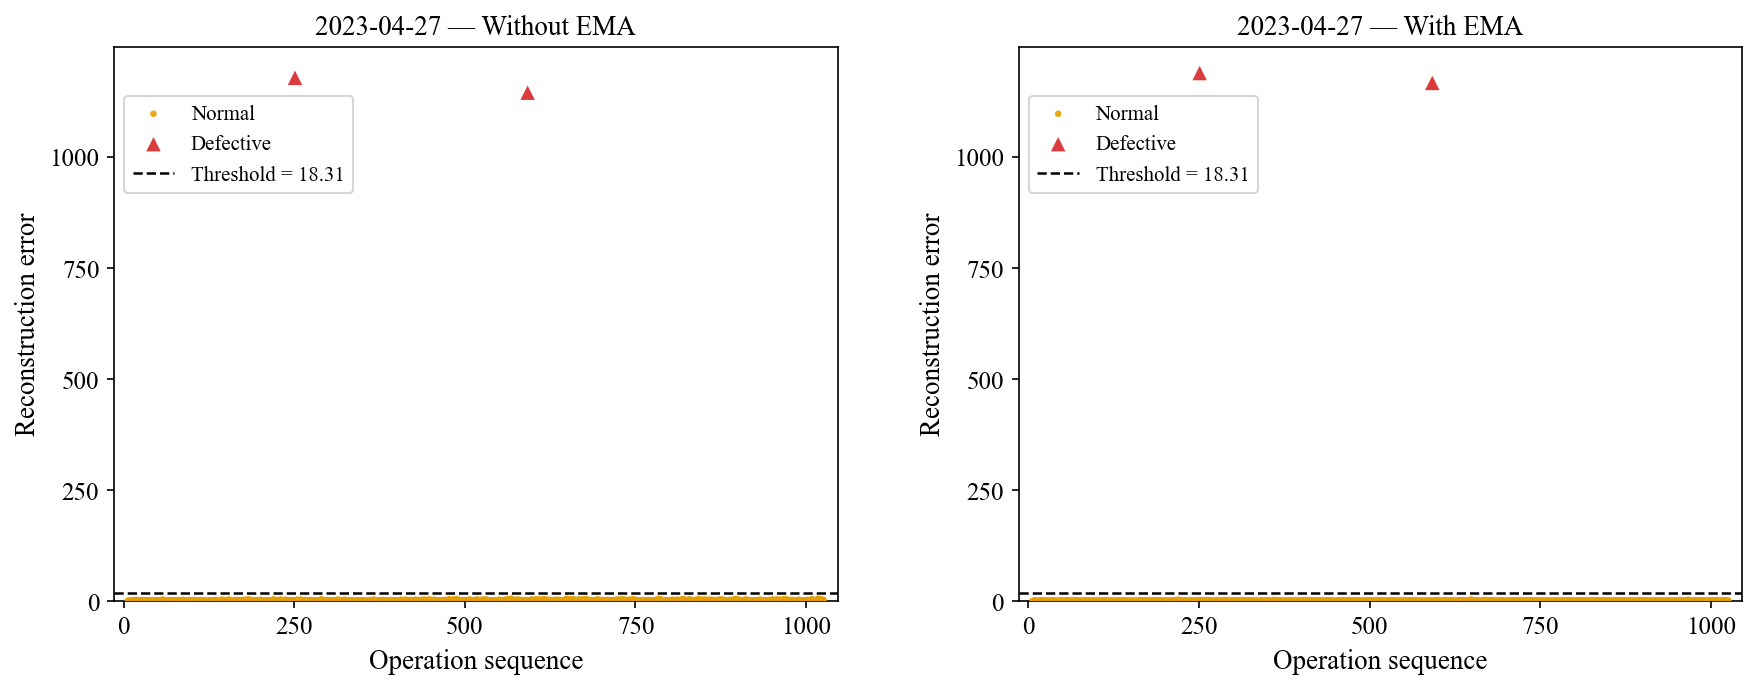

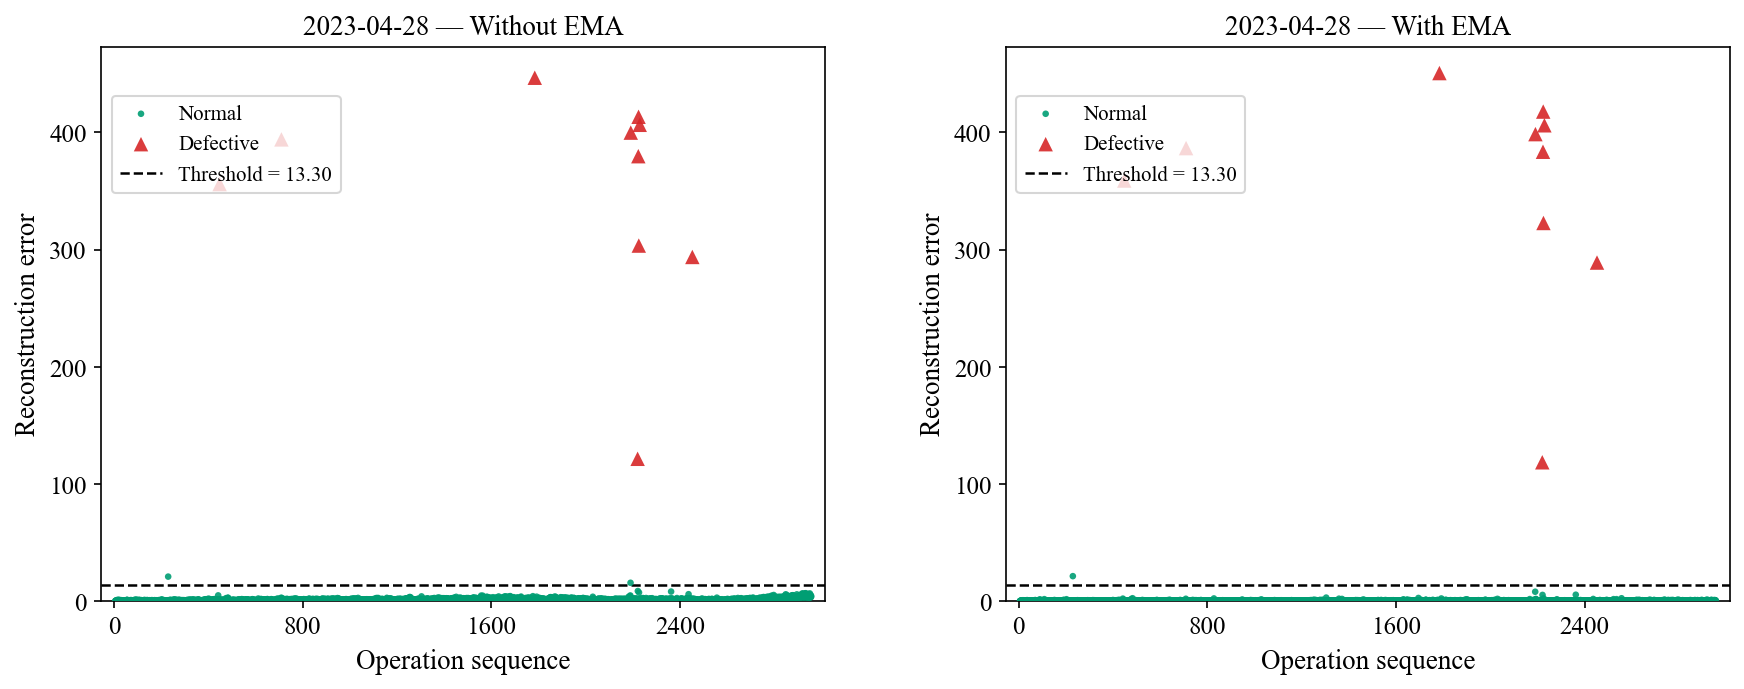

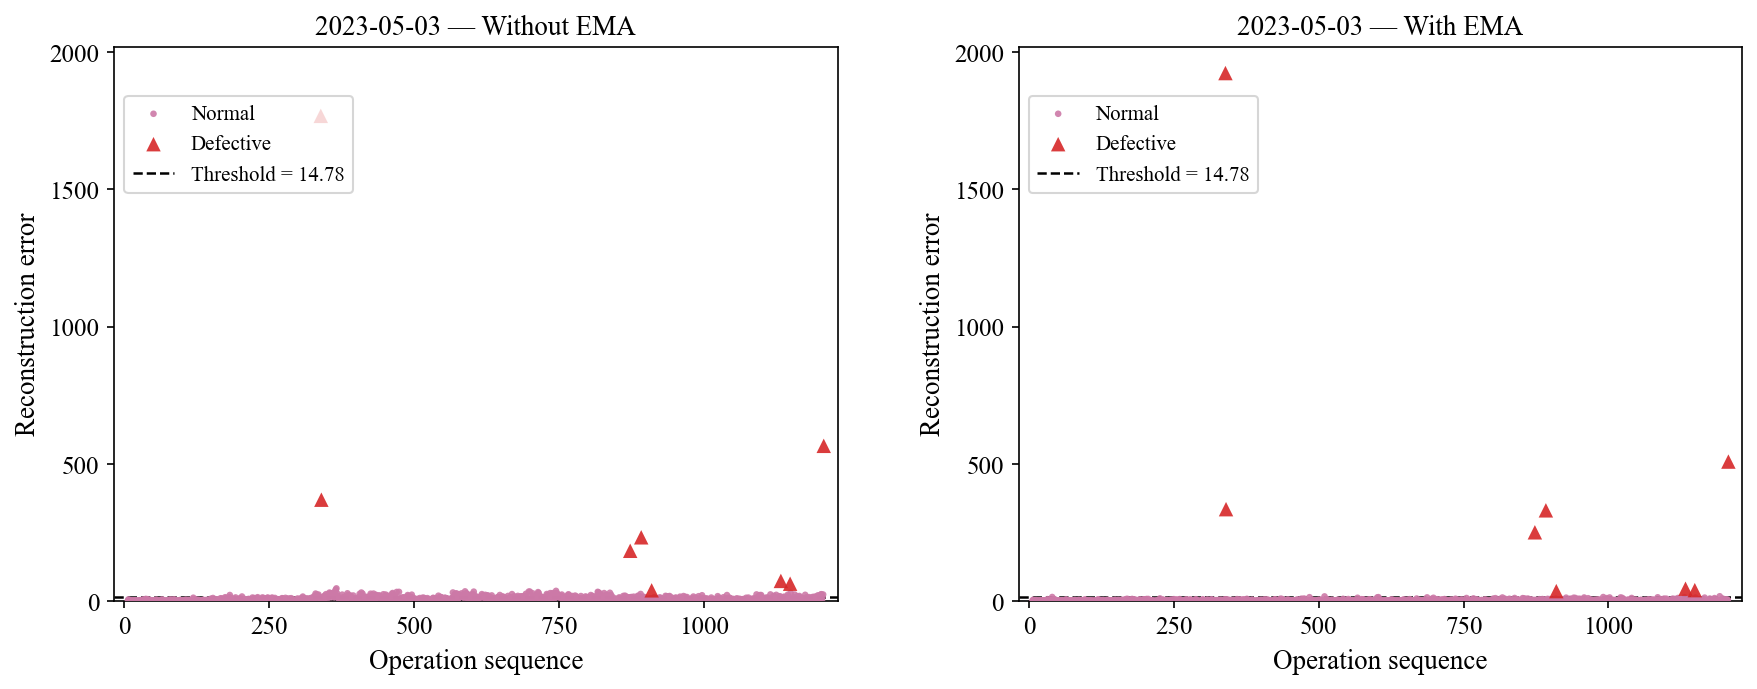

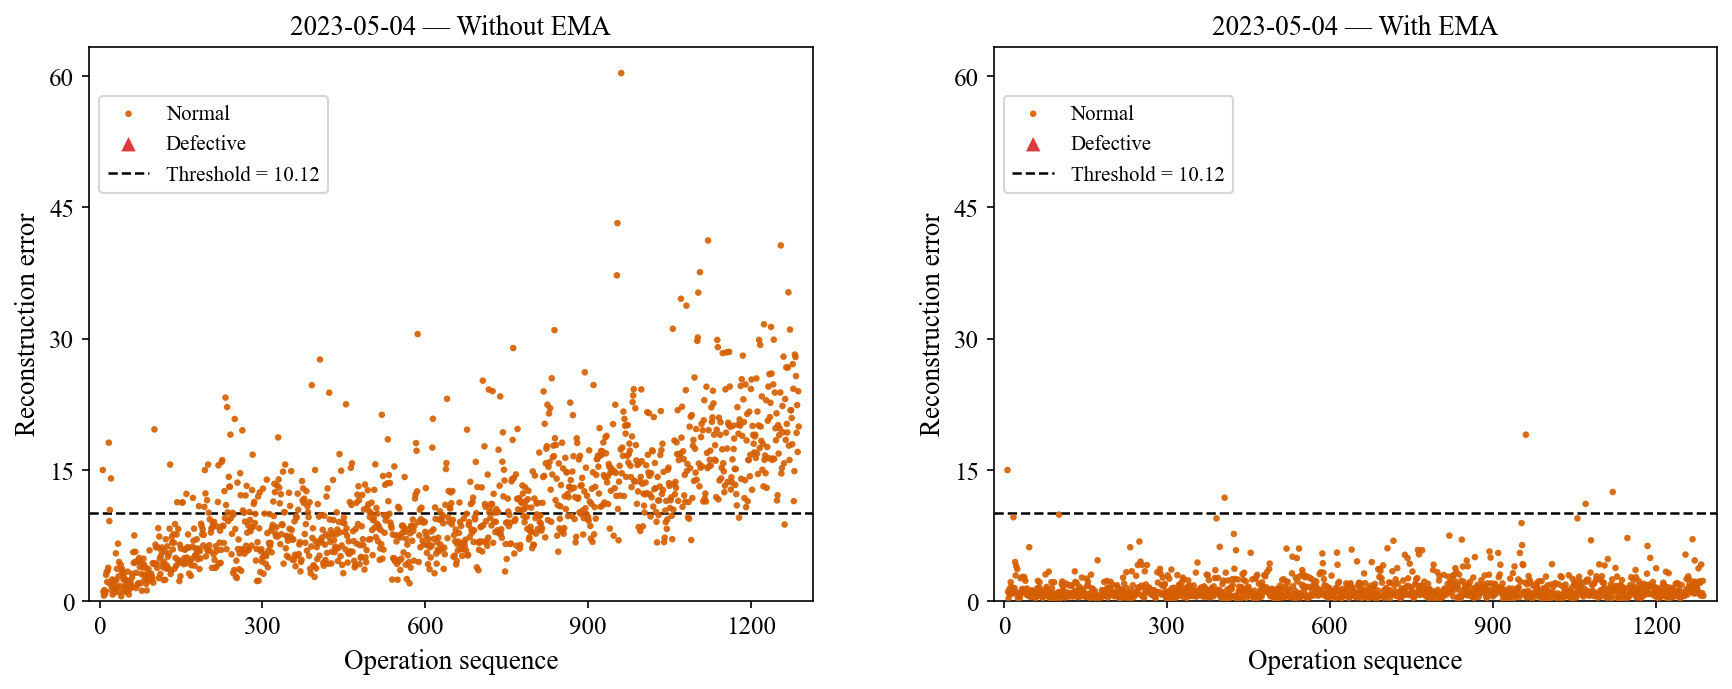

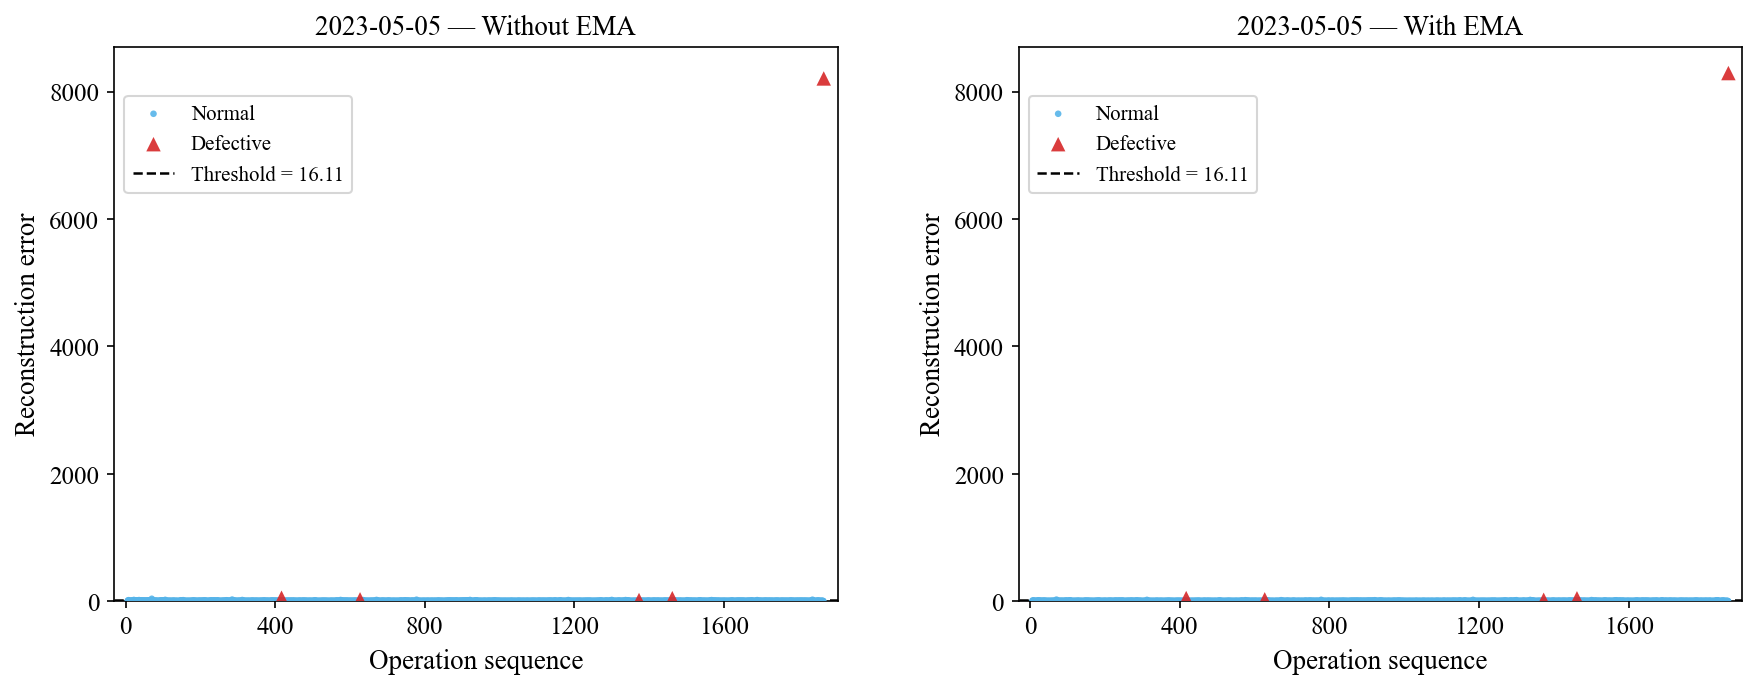

Dataset,Operation,Threshold,Without EMA,With EMA
2023-04-26,988,12.8560,1427.2794,1644.6428
2023-04-27,251,18.3111,1177.1773,1187.8507
2023-04-27,592,18.3111,1143.6878,1165.6241
2023-04-28,448,13.3030,355.8301,358.8193
2023-04-28,710,13.3030,393.9521,386.5109
2023-04-28,1784,13.3030,446.5580,450.5350
2023-04-28,2191,13.3030,399.7216,398.4414
2023-04-28,2220,13.3030,121.4076,118.4270
2023-04-28,2223,13.3030,379.6211,383.3994
2023-04-28,2224,13.3030,413.2364,417.6681


In [18]:
plot_defect_errors(results, full_range=True)
table(defect_errors)